Generating descriptions of KO abundances


In [1]:
import numpy as np

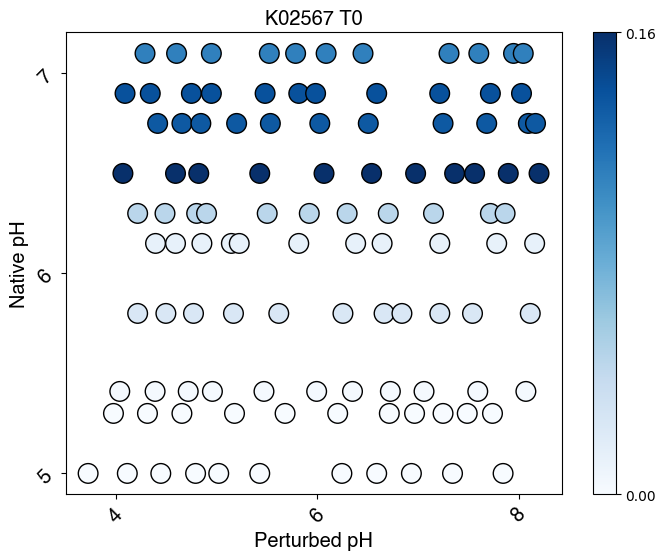

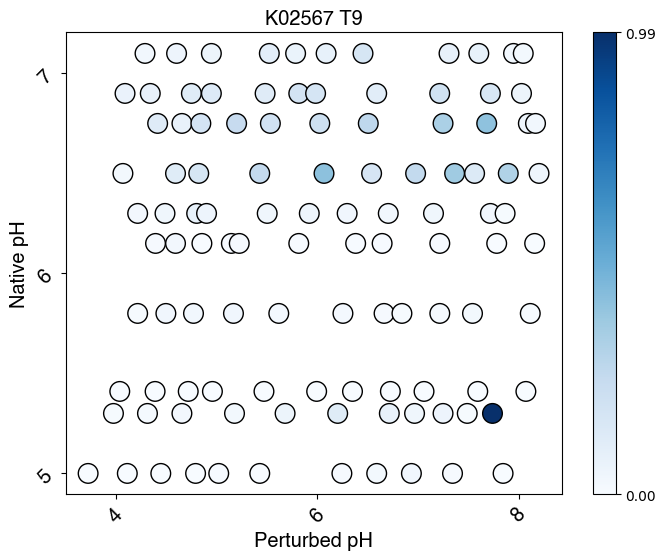

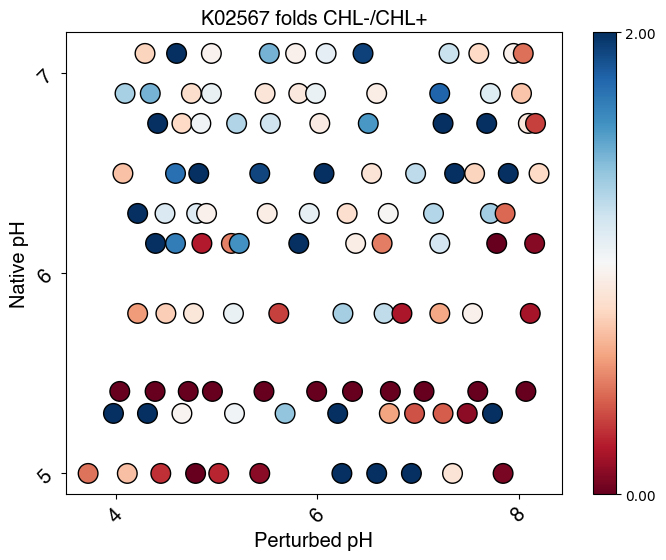

In [28]:
import numpy as np

import pandas as pd
from mgsa.helpers import plot

soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17'] 
prefixes = ['T0', 'Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17'] 

#given a KO, I want to build a native vs perturbed plot 
#I also want to specify if it is drug or no drug

#K05601 is a good phase III
#also K04561

#K17877 assimilatory nitrite reductase for regime III

#K00362: nirB

	
   
	 

KO = 'K02567'
scale = 1

T0 = np.zeros((10, 11))
T9_none = np.zeros((10, 11))
T9_drug = np.zeros((10, 11))

#collects the abundance, given a filepath, sample id, and KO number 
def get_abundance(file_path, sample_id, ko_number):
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split('\t')
            if parts[0] == sample_id and parts[1] == ko_number:
                return float(parts[-1])
    return 0

#T0 first
file_path = f'../data/KO_table/T0.KO_absolute_average_depth.tsv'
T0samples = pd.read_csv('../data/T0_sampleIDs.tsv', sep = '\t', header = None)
T0samples = T0samples.values
selected = [2, 4, 5, 8, 10, 11, 13, 14, 15, 16]
j = 0
for i, sample in enumerate(T0samples):
    if i in selected: 
        T0[j] = get_abundance(file_path, sample, KO)
        j += 1
        
        
#Next, T9

def perturbed_pH_sample(sample):
    metadata = pd.read_csv(f'../data/metadata.tsv', sep='\t')
    metadata = metadata.set_index('sample')
    return metadata.loc[sample, 'pH']

def samples(soil, drug = 'None'):
    sample_IDs = []
    metadata = pd.read_csv('../data/metadata.tsv', sep='\t')
    metadata = metadata.set_index('sample')
    soil_ = soil + '_'
    pHs = []
    for sample in metadata.index:
        if drug in sample and 'T9' in sample and soil_ in sample and 'Nitrate' not in sample:
            sample_IDs.append(sample)
            pHs.append(perturbed_pH_sample(sample))  
    #make sure the samples are organized by increaing perturbed pH
    pHs = np.array(pHs)
    sample_IDs = np.array(sample_IDs)
    indices = np.argsort(pHs)
    sample_IDs = sample_IDs[indices]
    sample_IDs = sample_IDs.tolist()
    return sample_IDs

for soil in soils:
    sample_ids = samples(soil, drug = 'None')
    file_path = f'../data/KO_table/{soil}.KO_absolute_average_depth.tsv'
    row_idx = soils.index(soil)
    for sample in sample_ids:
        col_idx = sample_ids.index(sample)
        T9_none[row_idx][col_idx] = get_abundance(file_path, sample, KO)
        
for soil in soils:
    sample_ids = samples(soil, drug = 'CHL')
    file_path = f'../data/KO_table/{soil}.KO_absolute_average_depth.tsv'
    row_idx = soils.index(soil)
    for sample in sample_ids:
        col_idx = sample_ids.index(sample)
        T9_drug[row_idx][col_idx] = get_abundance(file_path, sample, KO)
        
plot(T0, f'{KO} T0', vmin = 0)
plot(T9_none, f'{KO} T9', vmin = 0)
plot(T9_none / (T9_drug + 0.001*np.ones_like(T9_drug)), f'{KO} folds CHL-/CHL+', vmin = 0, vmax = 2, cmap = 'RdBu')
#plot(np.log((T9 + 0.01*np.ones_like(T9)) / (T0 + 0.01*np.ones_like(T0))), f'{KO} T9 change', cmap = 'RdBu', vmin = -1, vmax = 1)

#np.savetxt(f"../out/KO_abundances/T0data_{KO}.tsv", T0, delimiter = '\t', fmt = '%0.6f')
np.savetxt(f"../out/KO_abundances/T9data_{KO}_CHL.tsv", T9_drug, delimiter = '\t', fmt = '%0.6f')


### Compute KO table for rejected reads, specified taxa

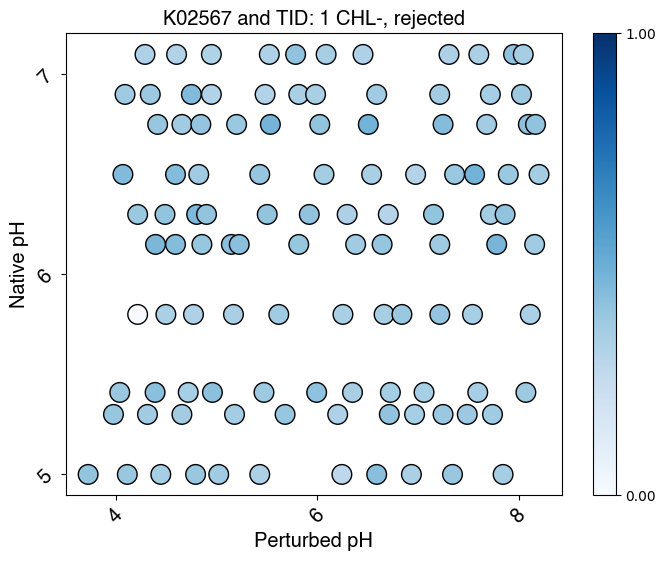

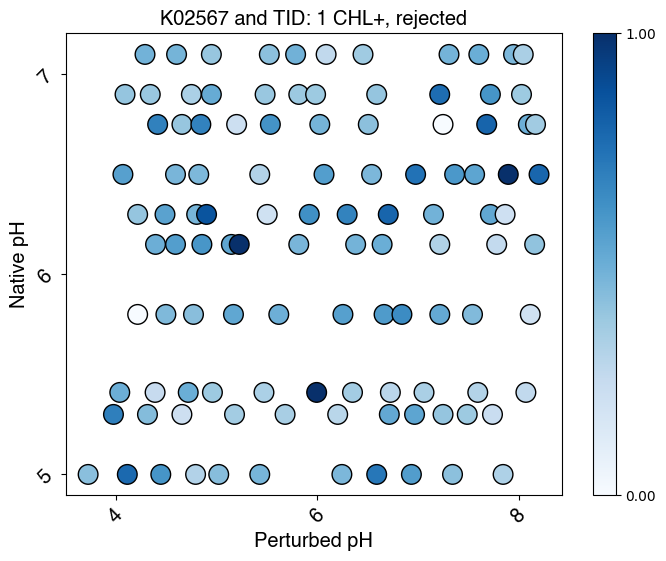

/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_62711/1252455248.py:60: RuntimeWarning: divide by zero encountered in log
  plot(np.log(T9_rej_none / (T9_rej_drug + 0.0001)), ' log (CHL-/CHL+ folds)', vmin = -1, vmax = 1, cmap = 'RdBu')


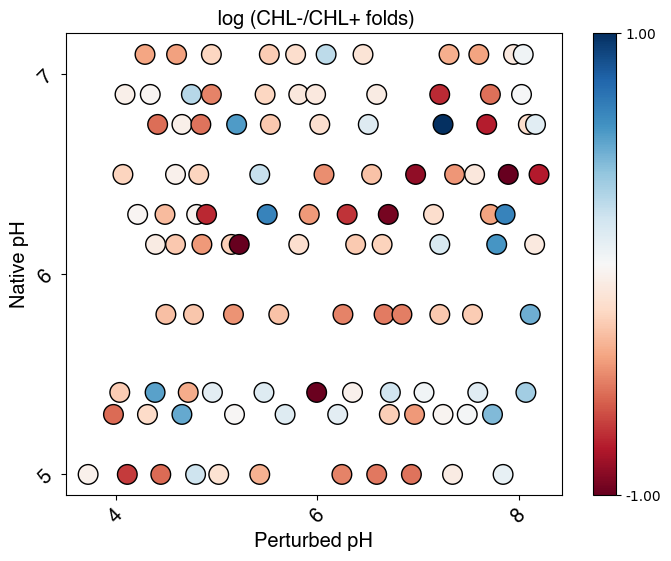

<Axes: title={'center': ' log (CHL-/CHL+ folds)'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [27]:
KO = 'K02567' #nirK: K00368
TID = '1'

#Parabacteroids: 2849180

table_path = '../data/tables/by_taxa'

T0 = np.zeros((10, 11))
T9_acc_none = np.zeros((10, 11))
T9_acc_drug = np.zeros((10, 11))

T9_rej_none = np.zeros((10, 11))
T9_rej_drug = np.zeros((10, 11))

#load the header
header = pd.read_csv(f'{table_path}/chl_neg_samples_{TID}_rejected.csv', nrows=0).columns.tolist()
first_col = header[0]

filtered_chl_neg = pd.read_csv(f'{table_path}/chl_neg_samples_{TID}_rejected.csv' , usecols=[first_col, KO]).fillna(0)
filtered_chl_pos = pd.read_csv(f'{table_path}/chl_pos_samples_{TID}_rejected.csv' , usecols=[first_col, KO]).fillna(0)

sample_list = filtered_chl_neg['Unnamed: 0'].values

def get_total_spikein(file_path, sample_id):
    #collect the total spikein in a specified sample
    #filepath is path to KO table
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split('\t')
            if parts[0] == sample_id:
                return float(parts[-2])
    return 0

def get_sample_idx(sample_list, sample_id):
    for idx, sample in enumerate(sample_list):
        if sample == sample_id:
            return idx
    return 0


##Collect data for rejected reads

for soil in soils:
    sample_ids = samples(soil, drug = 'None')
    file_path = f'../data/KO_table/{soil}.KO_absolute_average_depth.tsv'
    row_idx = soils.index(soil)
    for sample in sample_ids:
        col_idx = sample_ids.index(sample)
        idx = get_sample_idx(sample_list, sample)
        total_spikein = get_total_spikein(file_path, sample)
        filtered_reads_neg = filtered_chl_neg[KO].values
        filtered_reads_pos = filtered_chl_pos[KO].values
        if idx < 109:
            T9_rej_none[row_idx][col_idx] = filtered_reads_neg[idx]/total_spikein
            T9_rej_drug[row_idx][col_idx] = filtered_reads_pos[idx]/total_spikein
    

plot(T9_rej_none, f'{KO} and TID: {TID} CHL-, rejected', vmax = 1)
plot(T9_rej_drug, f'{KO} and TID: {TID} CHL+, rejected', vmax = 1)
plot(np.log(T9_rej_none / (T9_rej_drug + 0.0001)), ' log (CHL-/CHL+ folds)', vmin = -1, vmax = 1, cmap = 'RdBu')

### Compute KO table among rejected reads

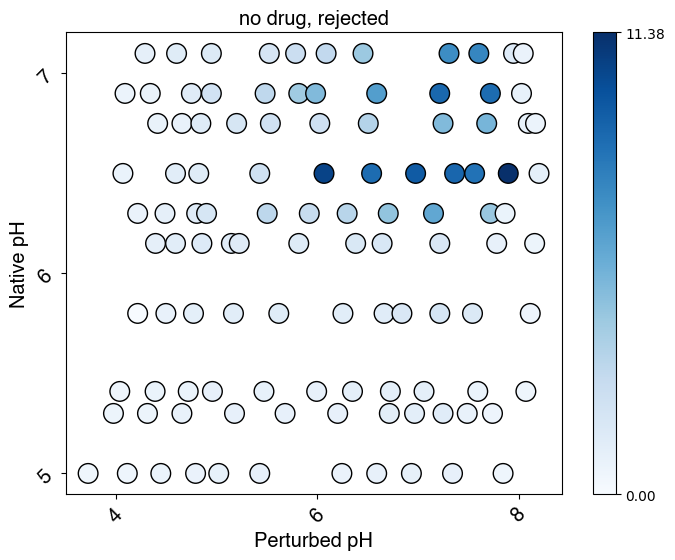

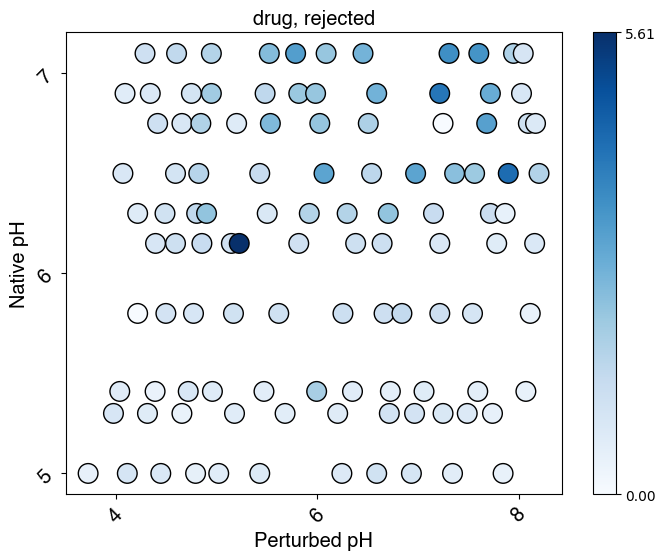

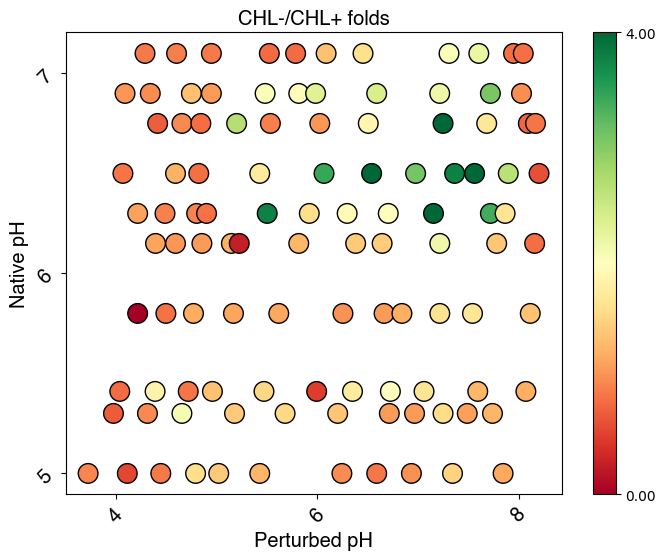

In [29]:
KO = 'K02567' #nirK: K00368


table_path = '../data/tables'

T0 = np.zeros((10, 11))
T9_acc_none = np.zeros((10, 11))
T9_acc_drug = np.zeros((10, 11))

T9_rej_none = np.zeros((10, 11))
T9_rej_drug = np.zeros((10, 11))

#load the header
header = pd.read_csv(f'{table_path}/chl_neg_samples_rejected.csv', nrows=0).columns.tolist()
first_col = header[0]

filtered_chl_neg = pd.read_csv(f'{table_path}/chl_neg_samples_rejected.csv' , usecols=[first_col, KO]).fillna(0)
filtered_chl_pos = pd.read_csv(f'{table_path}/chl_pos_samples_rejected.csv' , usecols=[first_col, KO]).fillna(0)

sample_list = filtered_chl_neg['Unnamed: 0'].values

def get_total_spikein(file_path, sample_id):
    #collect the total spikein in a specified sample
    #filepath is path to KO table
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split('\t')
            if parts[0] == sample_id:
                return float(parts[-2])
    return 0

def get_sample_idx(sample_list, sample_id):
    for idx, sample in enumerate(sample_list):
        if sample == sample_id:
            return idx
    return 0


##Collect data for rejected reads

for soil in soils:
    sample_ids = samples(soil, drug = 'None')
    file_path = f'../data/KO_table/{soil}.KO_absolute_average_depth.tsv'
    row_idx = soils.index(soil)
    for sample in sample_ids:
        col_idx = sample_ids.index(sample)
        idx = get_sample_idx(sample_list, sample)
        total_spikein = get_total_spikein(file_path, sample)
        filtered_reads_neg = filtered_chl_neg[KO].values
        filtered_reads_pos = filtered_chl_pos[KO].values
        if idx < 109:
            T9_rej_none[row_idx][col_idx] = filtered_reads_neg[idx]/total_spikein
            T9_rej_drug[row_idx][col_idx] = filtered_reads_pos[idx]/total_spikein
    

plot(T9_rej_none, 'no drug, rejected')
plot(T9_rej_drug, 'drug, rejected')
plot(T9_rej_none / (T9_rej_drug + 0.0001), 'CHL-/CHL+ folds', vmin = 0, vmax = 4, cmap = 'RdYlGn')

np.savetxt(f'../out/KO_abundances/T9data_{KO}_CHL_rej.tsv', T9_rej_drug, delimiter = '\t', fmt = '%0.6f')

### Produce the complete KO table for any KO

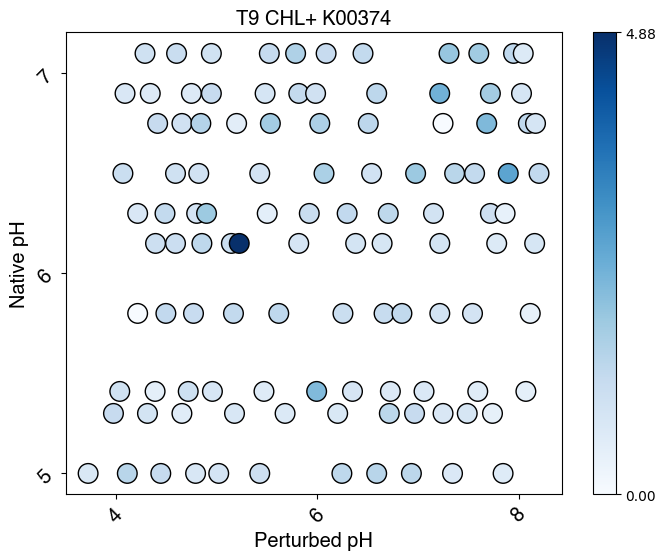

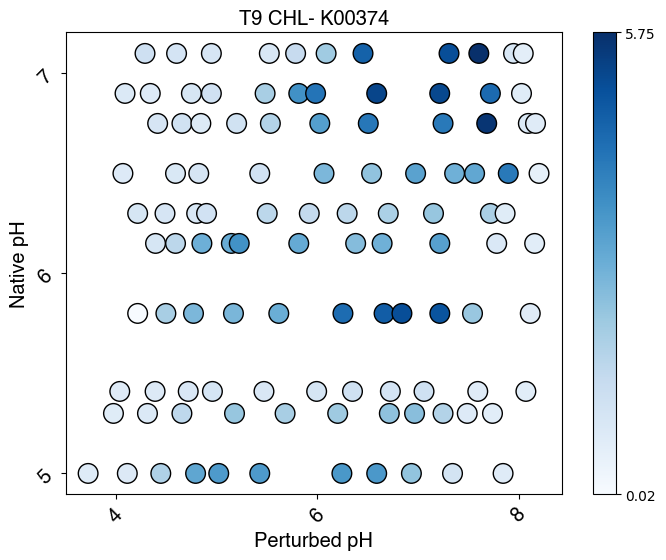

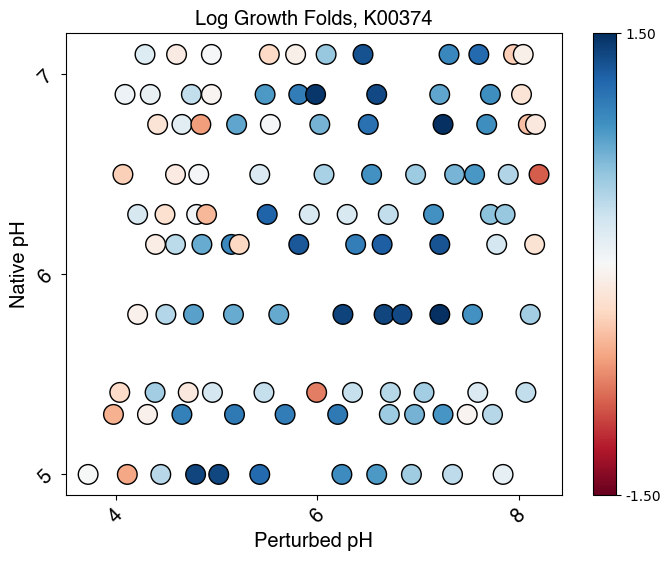

<Axes: title={'center': 'Log Growth Folds, K00374'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [44]:
import numpy as np

import pandas as pd
from mgsa.helpers import plot

soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17'] 
prefixes = ['T0', 'Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17'] 
	
   
	 

KO = 'K00374'
scale = 1

T0 = np.zeros((10, 11))
T9_none = np.zeros((10, 11))
T9_drug = np.zeros((10, 11))

#collects the abundance, given a filepath, sample id, and KO number 
def get_abundance(file_path, sample_id, ko_number):
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split('\t')
            if parts[0] == sample_id and parts[1] == ko_number:
                return float(parts[-1])
    return 0

#T0 first
file_path = f'../data/KO_table/T0.KO_absolute_average_depth.tsv'
T0samples = pd.read_csv('../data/T0_sampleIDs.tsv', sep = '\t', header = None)
T0samples = T0samples.values
selected = [2, 4, 5, 8, 10, 11, 13, 14, 15, 16]
j = 0
for i, sample in enumerate(T0samples):
    if i in selected: 
        T0[j] = get_abundance(file_path, sample, KO)
        j += 1
        
        
#Next, T9

def perturbed_pH_sample(sample):
    metadata = pd.read_csv(f'../data/metadata.tsv', sep='\t')
    metadata = metadata.set_index('sample')
    return metadata.loc[sample, 'pH']

def samples(soil, drug = 'None'):
    sample_IDs = []
    metadata = pd.read_csv('../data/metadata.tsv', sep='\t')
    metadata = metadata.set_index('sample')
    soil_ = soil + '_'
    pHs = []
    for sample in metadata.index:
        if drug in sample and 'T9' in sample and soil_ in sample and 'Nitrate' not in sample:
            sample_IDs.append(sample)
            pHs.append(perturbed_pH_sample(sample))  
    #make sure the samples are organized by increaing perturbed pH
    pHs = np.array(pHs)
    sample_IDs = np.array(sample_IDs)
    indices = np.argsort(pHs)
    sample_IDs = sample_IDs[indices]
    sample_IDs = sample_IDs.tolist()
    return sample_IDs

for soil in soils:
    sample_ids = samples(soil, drug = 'None')
    file_path = f'../data/KO_table/{soil}.KO_absolute_average_depth.tsv'
    row_idx = soils.index(soil)
    for sample in sample_ids:
        col_idx = sample_ids.index(sample)
        T9_none[row_idx][col_idx] = get_abundance(file_path, sample, KO)
        
for soil in soils:
    sample_ids = samples(soil, drug = 'CHL')
    file_path = f'../data/KO_table/{soil}.KO_absolute_average_depth.tsv'
    row_idx = soils.index(soil)
    for sample in sample_ids:
        col_idx = sample_ids.index(sample)
        T9_drug[row_idx][col_idx] = get_abundance(file_path, sample, KO)
        
# plot(T0, f'{KO} T0', vmin = 0)
# plot(T9_none, f'{KO} T9', vmin = 0)
# plot(T9_none / (T9_drug + 0.001*np.ones_like(T9_drug)), f'{KO} folds CHL-/CHL+', vmin = 0, vmax = 2, cmap = 'RdBu')
#plot(np.log((T9 + 0.01*np.ones_like(T9)) / (T0 + 0.01*np.ones_like(T0))), f'{KO} T9 change', cmap = 'RdBu', vmin = -1, vmax = 1)

#np.savetxt(f"../out/KO_abundances/T0data_{KO}.tsv", T0, delimiter = '\t', fmt = '%0.6f')
np.savetxt(f"../out/KO_abundances/T9data_{KO}_CHL.tsv", T9_drug, delimiter = '\t', fmt = '%0.6f')

table_path = '../data/tables'

T0 = np.zeros((10, 11))
T9_acc_none = np.zeros((10, 11))
T9_acc_drug = np.zeros((10, 11))

T9_rej_none = np.zeros((10, 11))
T9_rej_drug = np.zeros((10, 11))

#load the header
header = pd.read_csv(f'{table_path}/chl_neg_samples_rejected.csv', nrows=0).columns.tolist()
first_col = header[0]

filtered_chl_neg = pd.read_csv(f'{table_path}/chl_neg_samples_rejected.csv' , usecols=[first_col, KO]).fillna(0)
filtered_chl_pos = pd.read_csv(f'{table_path}/chl_pos_samples_rejected.csv' , usecols=[first_col, KO]).fillna(0)

sample_list = filtered_chl_neg['Unnamed: 0'].values

def get_total_spikein(file_path, sample_id):
    #collect the total spikein in a specified sample
    #filepath is path to KO table
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split('\t')
            if parts[0] == sample_id:
                return float(parts[-2])
    return 0

def get_sample_idx(sample_list, sample_id):
    for idx, sample in enumerate(sample_list):
        if sample == sample_id:
            return idx
    return 0


##Collect data for rejected reads

for soil in soils:
    sample_ids = samples(soil, drug = 'None')
    file_path = f'../data/KO_table/{soil}.KO_absolute_average_depth.tsv'
    row_idx = soils.index(soil)
    for sample in sample_ids:
        col_idx = sample_ids.index(sample)
        idx = get_sample_idx(sample_list, sample)
        total_spikein = get_total_spikein(file_path, sample)
        filtered_reads_neg = filtered_chl_neg[KO].values
        filtered_reads_pos = filtered_chl_pos[KO].values
        if idx < 109:
            T9_rej_none[row_idx][col_idx] = filtered_reads_neg[idx]/total_spikein
            T9_rej_drug[row_idx][col_idx] = filtered_reads_pos[idx]/total_spikein 
    

# plot(T9_rej_none, 'no drug, rejected')
# plot(T9_rej_drug, 'drug, rejected')
# plot(T9_rej_none / (T9_rej_drug + 0.0001), 'CHL-/CHL+ folds', vmin = 0, vmax = 4, cmap = 'RdYlGn')

np.savetxt(f'../out/KO_abundances/T9data_{KO}_CHL_rej.tsv', T9_rej_drug, delimiter = '\t', fmt = '%0.6f')
np.savetxt(f'../out/KO_abundances/T9data_{KO}_CHL_tot.tsv', T9_rej_drug + T9_drug, delimiter = '\t', fmt = '%0.6f')
np.savetxt(f'../out/KO_abundances/T9data_{KO}_none_tot.tsv', T9_rej_none + T9_none, delimiter = '\t', fmt = '%0.6f')

plot(T9_rej_drug + T9_drug, f'T9 CHL+ {KO}')
plot(T9_rej_none + T9_none, f'T9 CHL- {KO}')
plot(np.log((T9_rej_none + T9_none)/(T9_rej_drug + T9_drug + 0.0001)), f'Log Growth Folds, {KO}', vmin = -1.5, vmax = 1.5, cmap = 'RdBu')


### Compute the 'genomic distribution' of nitrate reducers, including rejected reads

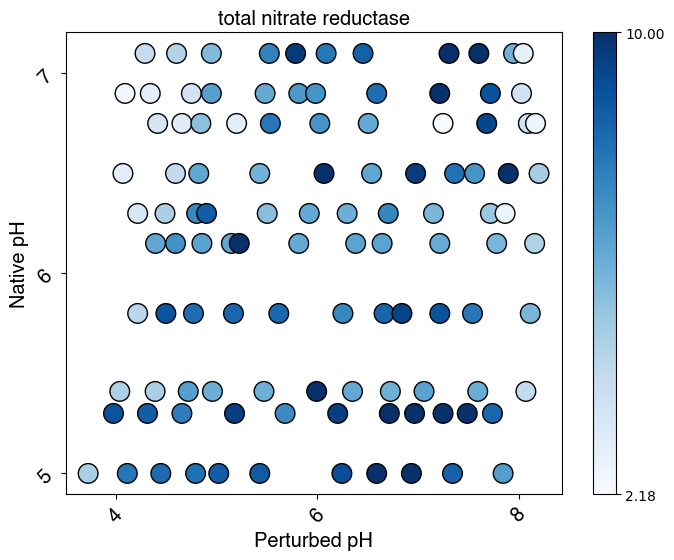

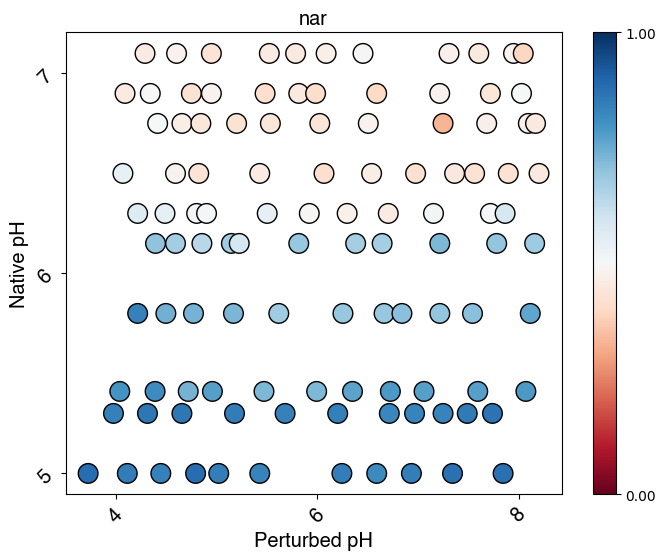

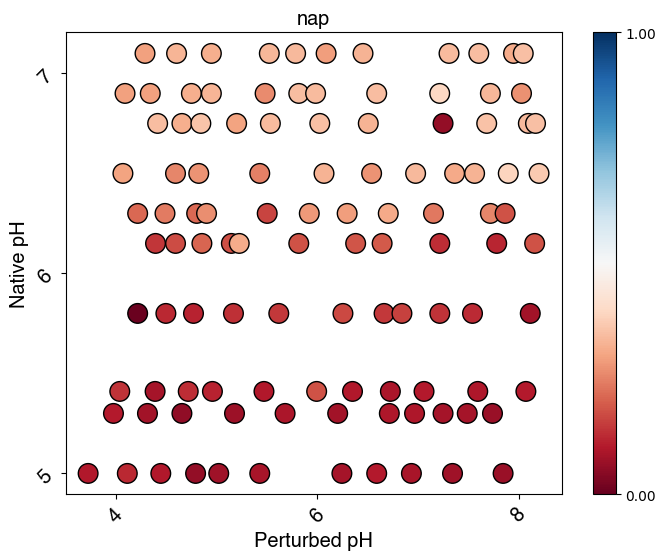

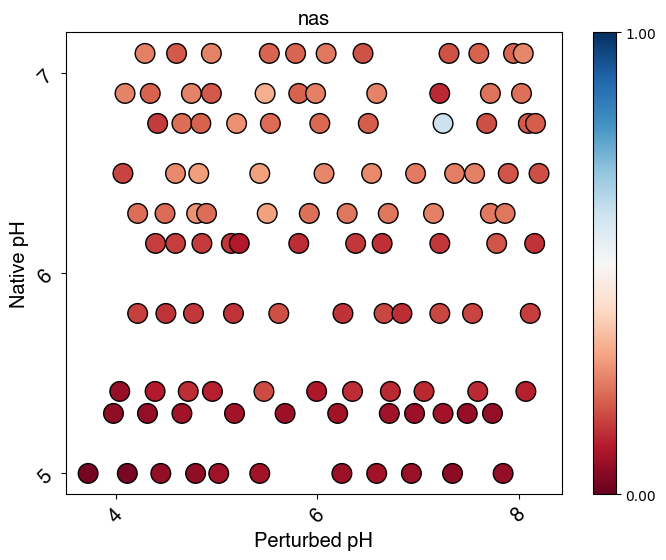

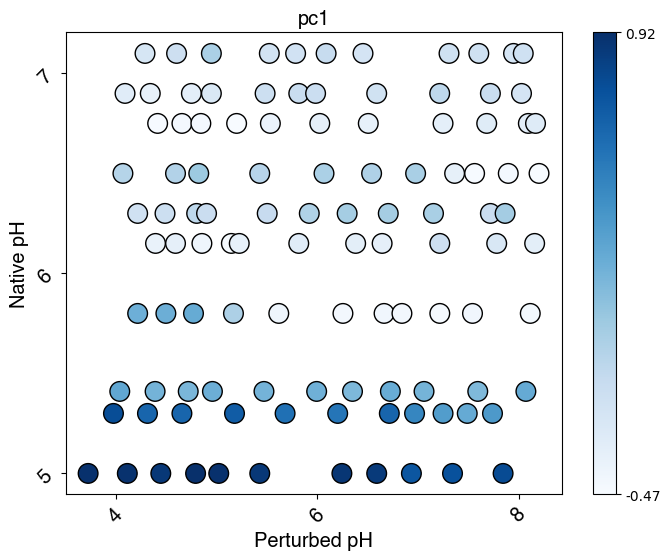

Variance explained by PC1: 0.972095417434912
PC1 loadings (which variants contribute): [0.57523921 0.58273044 0.57404275]


In [38]:
from sklearn.decomposition import PCA

nar_acc = pd.read_csv('../out/KO_abundances/T9data_K00370_CHL.tsv', sep = '\t', header = None).values
nar_rej = pd.read_csv('../out/KO_abundances/T9data_K00370_CHL_rej.tsv', sep = '\t', header = None).values

nar = nar_acc + nar_rej

nap_acc = pd.read_csv('../out/KO_abundances/T9data_K02567_CHL.tsv', sep = '\t', header = None).values
nap_rej = pd.read_csv('../out/KO_abundances/T9data_K02567_CHL_rej.tsv', sep = '\t', header = None).values

nap = nap_acc + nap_rej

nas_acc = pd.read_csv('../out/KO_abundances/T9data_K00372_CHL.tsv', sep = '\t', header = None).values
nas_rej = pd.read_csv('../out/KO_abundances/T9data_K00372_CHL_rej.tsv', sep = '\t', header = None).values

nas = nas_acc + nas_rej


X_gen = np.stack([nar, nap, nas])

plot(X_gen[0] + X_gen[1] + X_gen[2], 'total nitrate reductase', vmax = 10)

X_gen = X_gen / np.sum(X_gen, 0, keepdims=True)

plot(X_gen[0], 'nar', vmin = 0, vmax = 1, cmap = 'RdBu')
plot(X_gen[1], 'nap', vmin = 0, vmax = 1, cmap = 'RdBu')
plot(X_gen[2], 'nas', vmin = 0, vmax = 1, cmap = 'RdBu')




X_flat = X_gen.reshape(110, 3) #broad cast the variant distribution from (10,11) to (110)
pca = PCA()
pca_components = pca.fit_transform(X_flat)
X_gen_pc1 = pca_components[:, 0].reshape(10,11)
plot(X_gen_pc1, 'pc1')
print("Variance explained by PC1:", pca.explained_variance_ratio_[0])
print("PC1 loadings (which variants contribute):", pca.components_[0])


np.savetxt(f'../out/KO_abundances/T9_nar_total_CHL.tsv', nar, delimiter = '\t', fmt = '%0.6f')
np.savetxt(f'../out/genome_dist/T9dist_nitrate_CHL_nar.tsv', X_gen[:,:,0], delimiter = '\t', fmt = '%0.6f')
np.savetxt(f'../out/genome_dist/T9dist_nitrate_CHL_nap.tsv', X_gen[:,:,1], delimiter = '\t', fmt = '%0.6f')
np.savetxt(f'../out/genome_dist/T9dist_nitrate_CHL_nas.tsv', X_gen[:,:,2], delimiter = '\t', fmt = '%0.6f')
np.savetxt(f'../out/genome_dist/T9dist_nitrate_CHL_pc1.tsv', X_gen_pc1, delimiter = '\t', fmt = '%0.6f')

I want the same function as above, but for ORFs

In [5]:
KO = 'K00370'
drug = 'None'
map = '09'
fpath = f'../out/orf_ids/cluster_ids_{map}_{KO}.tsv'
id_list = pd.read_csv(fpath, sep = '\t', header = None)
id_list = id_list.values
id_list = [id[0] for id in id_list]
#example
ORF = 'Soil16.scaffold_1328109982_c1_1'

idx = id_list.index(ORF)


data = []
for soil in soils: 
    data_all = pd.read_csv(f"../out/{KO}abundances/{soil}data_{map}_{drug}_{KO}.tsv", sep='\t', header=None)
    data_all = data_all.values
    data.append(data_all[idx])

data = [datum.tolist() for datum in data]

for datum in data:
    print(datum)
    



[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.001341, 0.004025, 0.00111, 0.00488, 0.014095, 0.004553, 0.00605, 0.004125, 0.01091, 0.003357, 0.008181]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [6]:
from mgsa.io import get_data

KO = 'K00370'
map = '09'
Drug = 'None'

complete_ids = pd.read_csv(f'../out/aaseqs/{KO}/long_complete_orf_ids.txt', header = None)
complete_ids = complete_ids.values
print(complete_ids.shape, complete_ids.dtype)

all_ids = pd.read_csv(f'../out/orf_ids/cluster_ids_{map}_{KO}.tsv', sep = '\t', header=None)

map = pd.read_csv(f'../out/aaseqs/{KO}/incomplete_to_complete_seq_mapping.tsv', sep = '\t')
map = map.values
print(map[:,1].shape, map[:,1].dtype)
print(map)

T0data = np.zeros((len(complete_ids), 20))
T9data = np.zeros((len(complete_ids), 10, 11))
T9drug = np.zeros((len(complete_ids), 10, 11))

for i, id in enumerate(complete_ids):
    got_data = get_data(id, drug = Drug, KO=KO)
    T0data[i] += got_data[0]
    T9data[i] += got_data[1]

print(T9data[:,:,1].shape)

for i, id in enumerate(map[:,0]):
    complete_id = map[i, 1]
    idx = np.where(complete_ids == complete_id)[0][0]
    got_data = get_data(id, drug = Drug)
    T0data[idx] += got_data[0]
    T9data[idx] += got_data[1]
    
for i, id in enumerate(complete_ids):
    got_data = get_data(id, drug = 'CHL', KO=KO)
    T9drug[i] += got_data[1]

print(T9data[:,:,1].shape)

for i, id in enumerate(map[:,0]):
    complete_id = map[i, 1]
    idx = np.where(complete_ids == complete_id)[0][0]
    got_data = get_data(id, drug = 'CHL')
    T9drug[idx] += got_data[1]



(57, 1) object
(451,) object
[['Soil11.scaffold_669406189_c1_1' 'Soil9.scaffold_209032411_c1_3'
  5.449392712550607]
 ['Soil11.scaffold_168782194_c1_1' 'Soil9.scaffold_209032411_c1_3'
  4.704142011834319]
 ['Soil11.scaffold_603781636_c1_1' 'Soil15.scaffold_116822102_c1_19'
  4.966360856269113]
 ...
 ['T0.scaffold_685359621_c1_1' 'Soil6.scaffold_312871021_c1_4'
  4.787878787878788]
 ['T0.scaffold_925671294_c1_1' 'Soil17.scaffold_274056314_c1_61'
  4.8262108262108265]
 ['T0.scaffold_409096425_c1_1' 'Soil5.scaffold_183283646_c1_24'
  5.014767932489452]]
(57, 10)
(57, 10)


Soil11.scaffold_431547323_c1_2


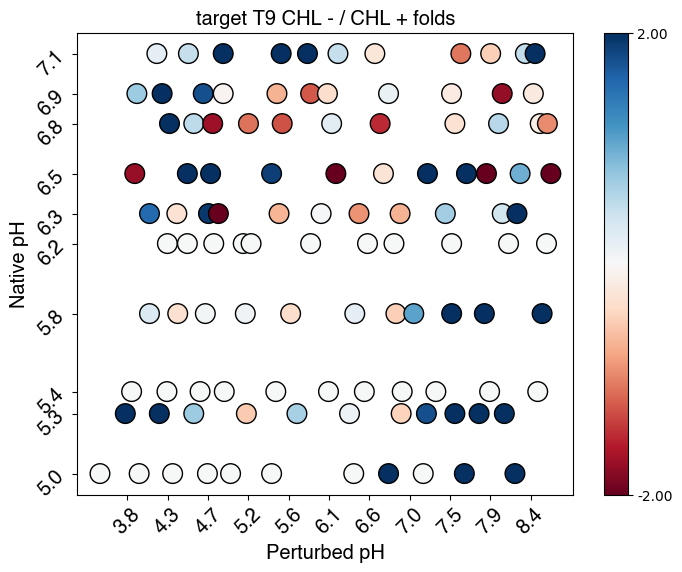

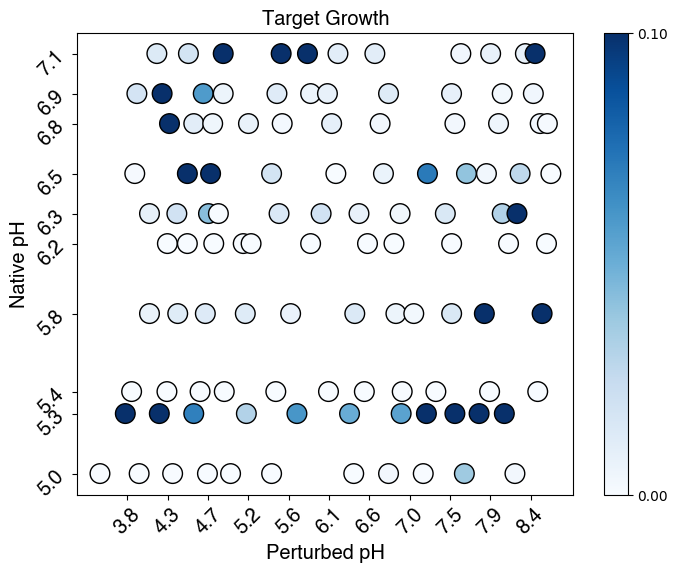

In [26]:



ids = [item[0] for item in complete_ids]

target_id = 'Soil17.scaffold_1045002370_c1_23'

groups = pd.read_csv('../out/groups/assignments_K00370_v2.tsv', sep = '\t', header = None).values
print(groups[0][0][:-2])

data_none = np.zeros((10,11))
data_drug = np.zeros((10,11))

group_num = 3
for i in range(len(groups)):
    if (int(groups[i][0][-1]) == group_num):
        data_none += T9data[ids.index(groups[i][0][:-2])]
        data_drug += T9drug[ids.index(groups[i][0][:-2])]

plot(np.log((data_none + 0.0001)/(data_drug + 0.0001)), 'target T9 CHL - / CHL + folds', vmin = -2, vmax = 2, cmap = 'RdBu')
plot(data_none, 'Target Growth', cmap = 'Blues', vmax = 0.1)

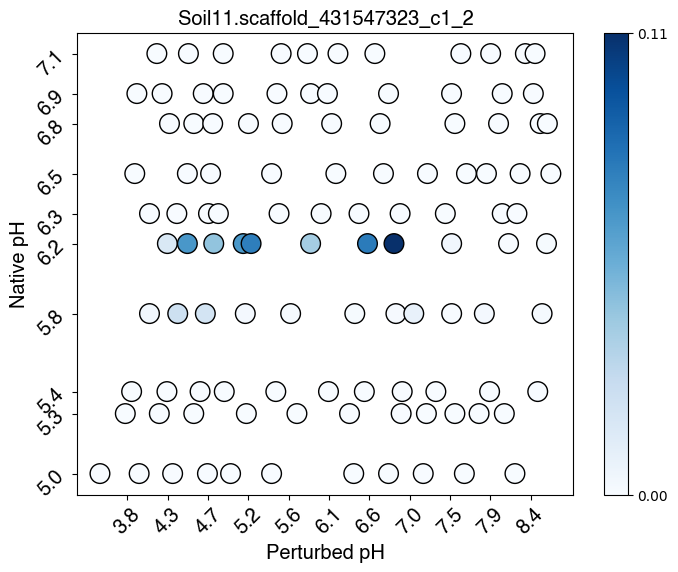

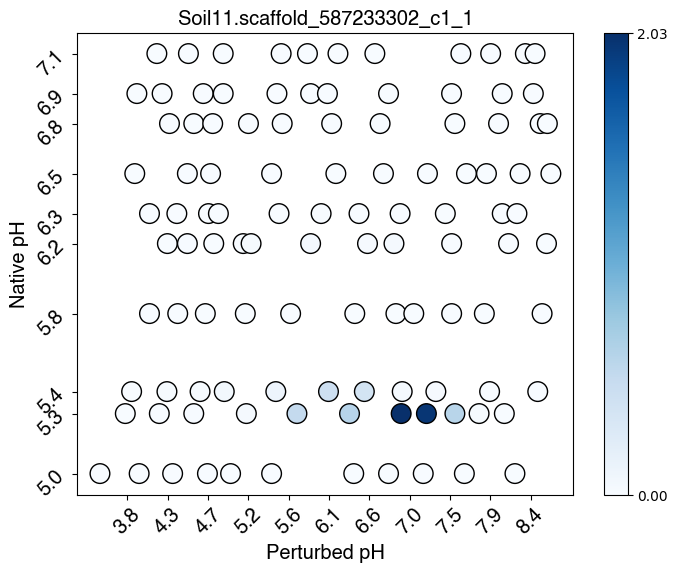

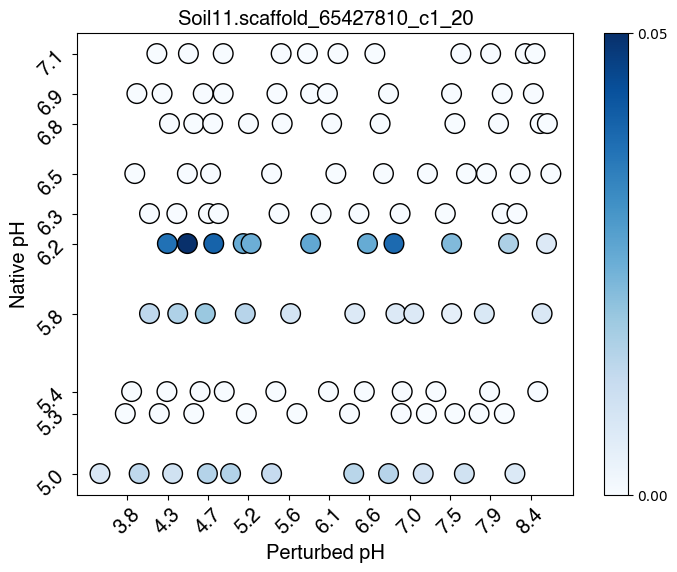

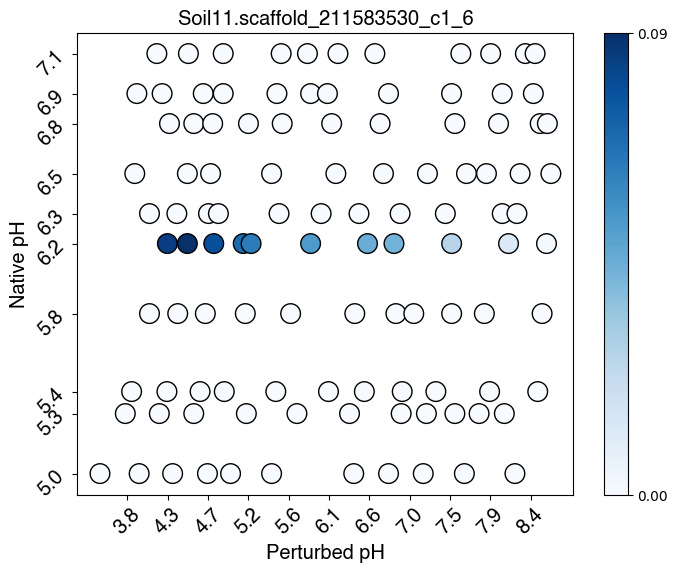

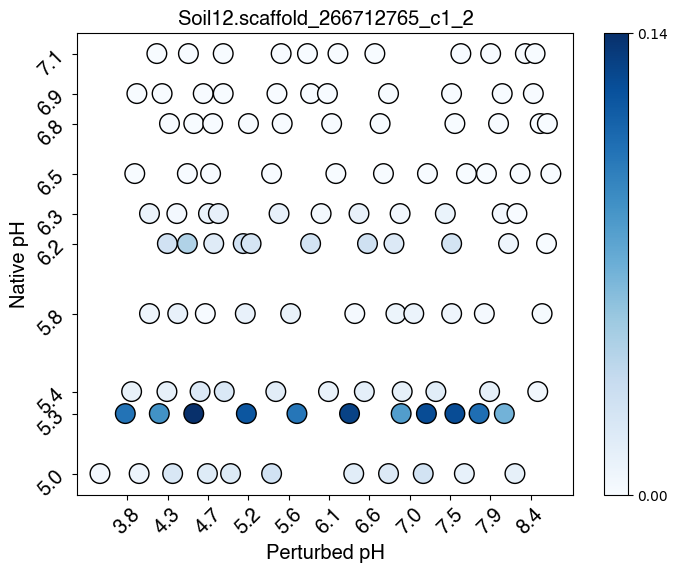

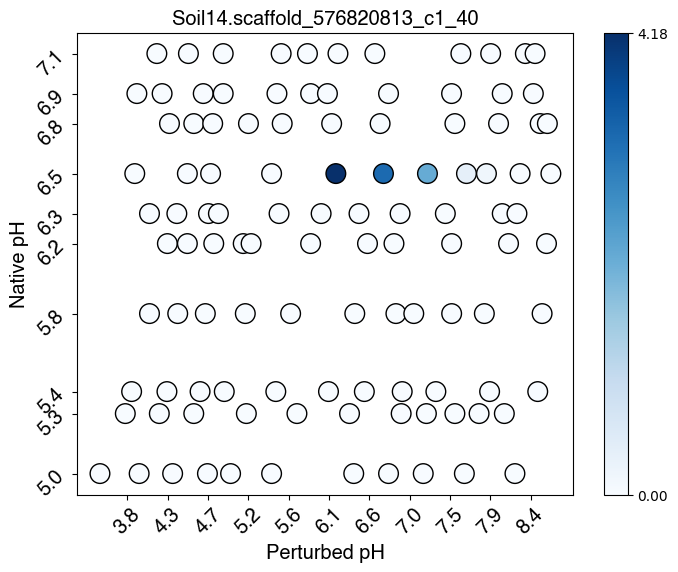

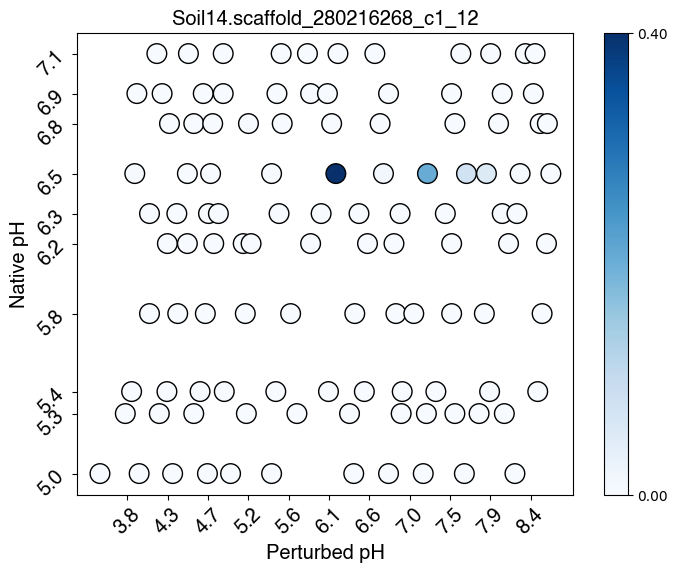

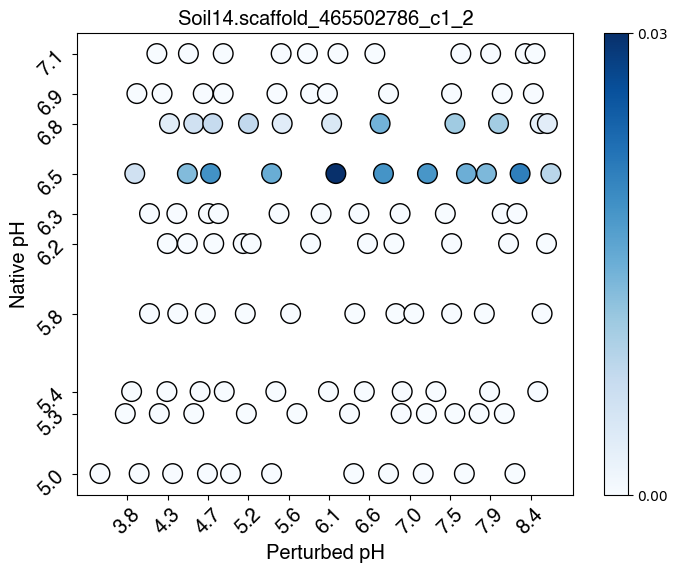

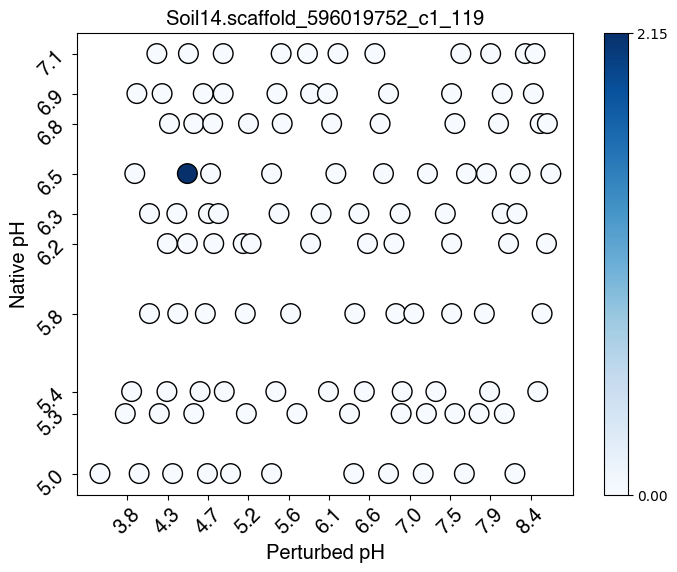

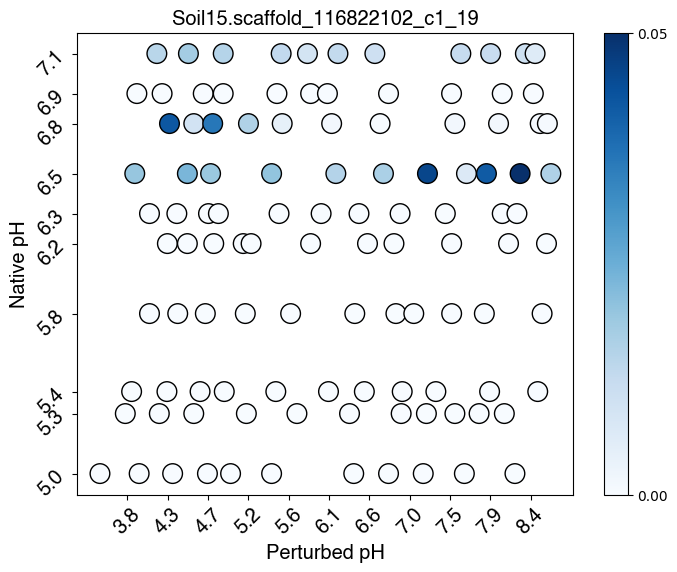

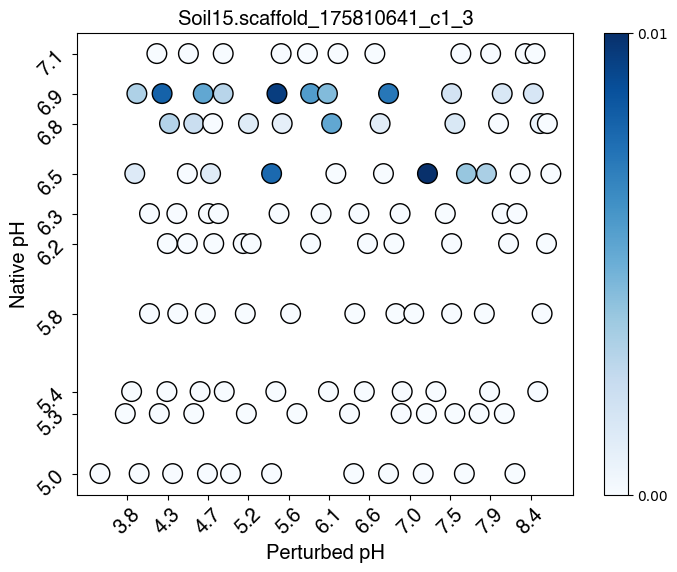

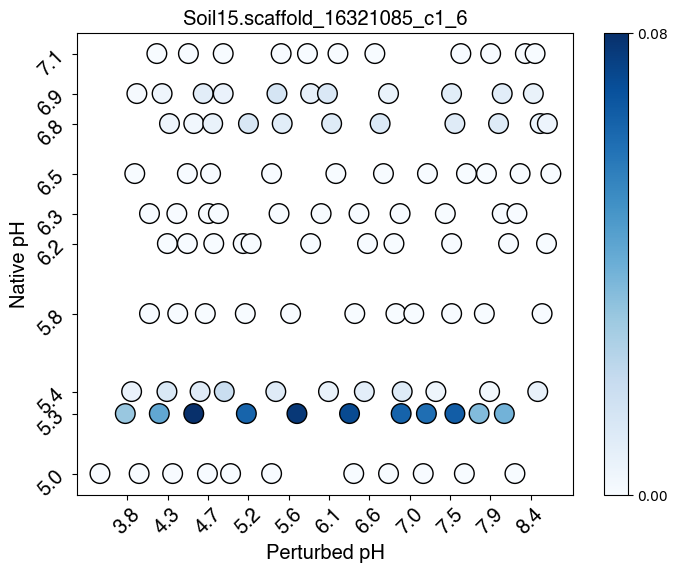

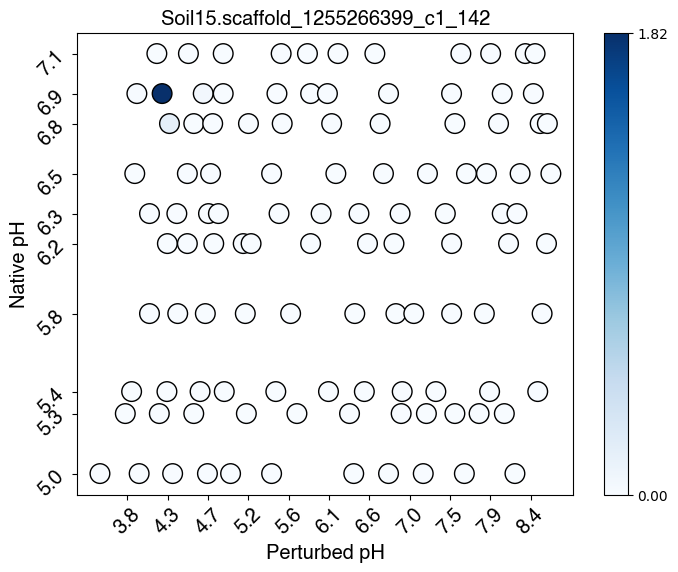

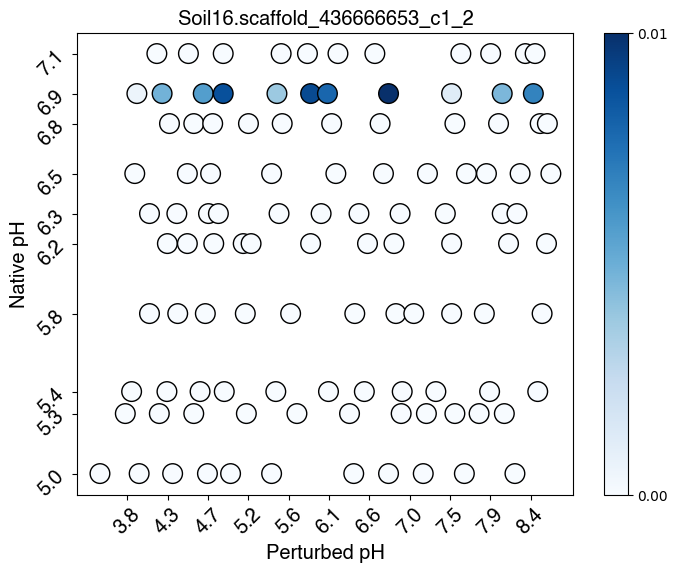

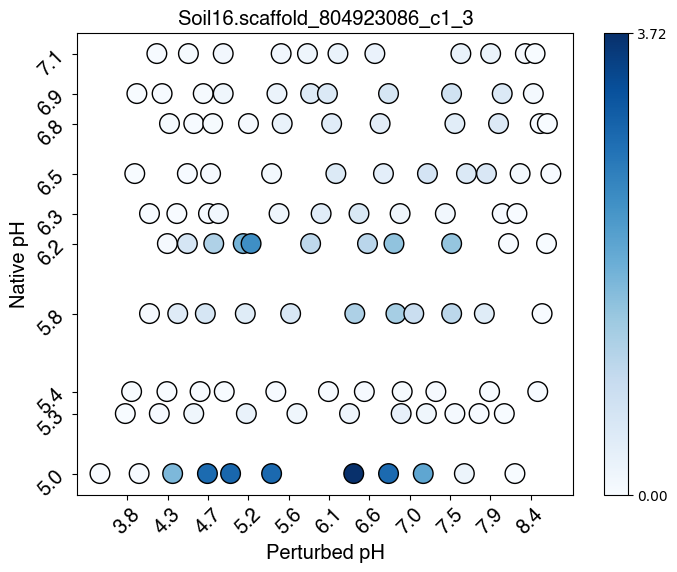

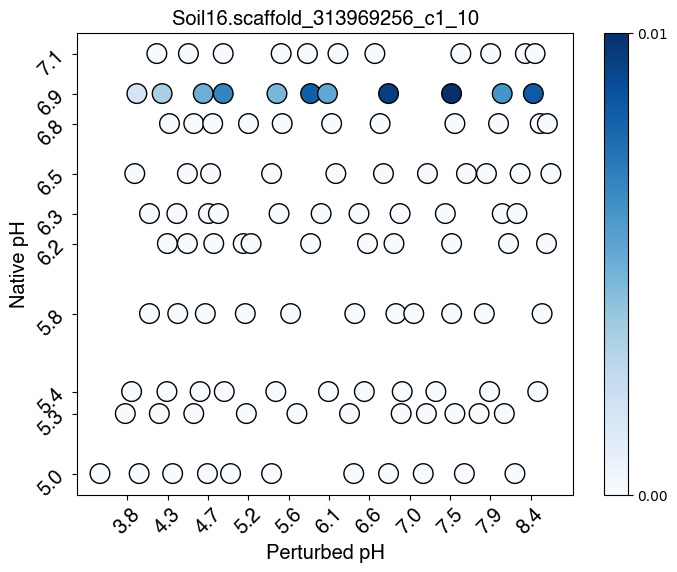

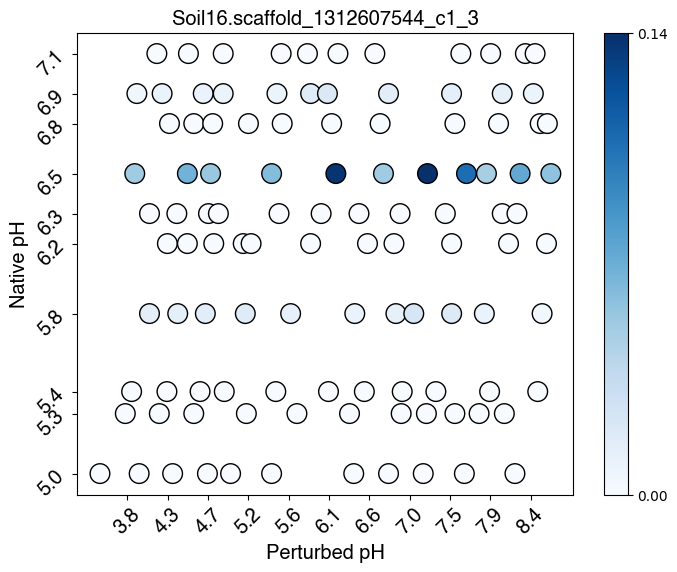

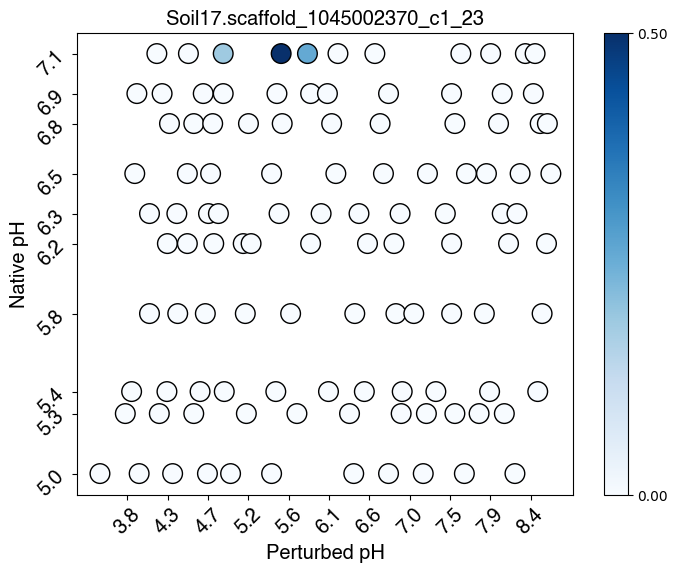

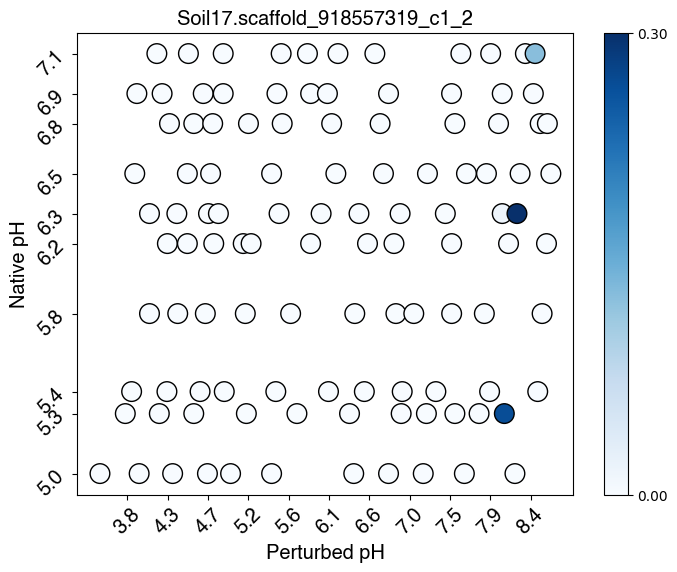

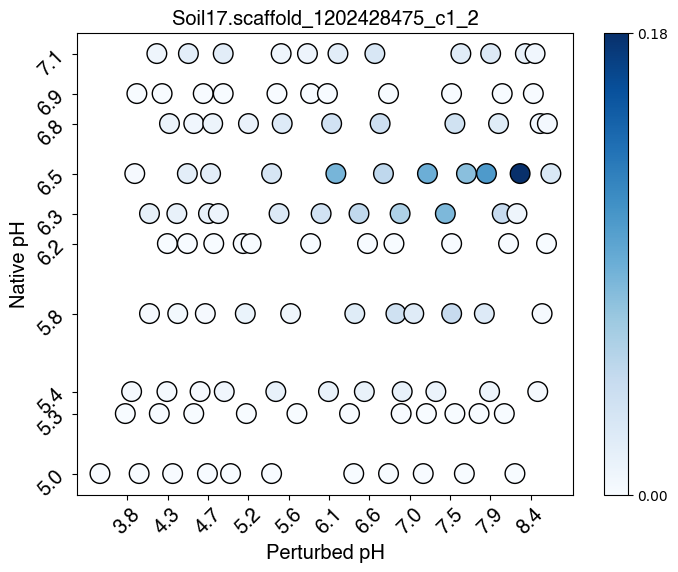

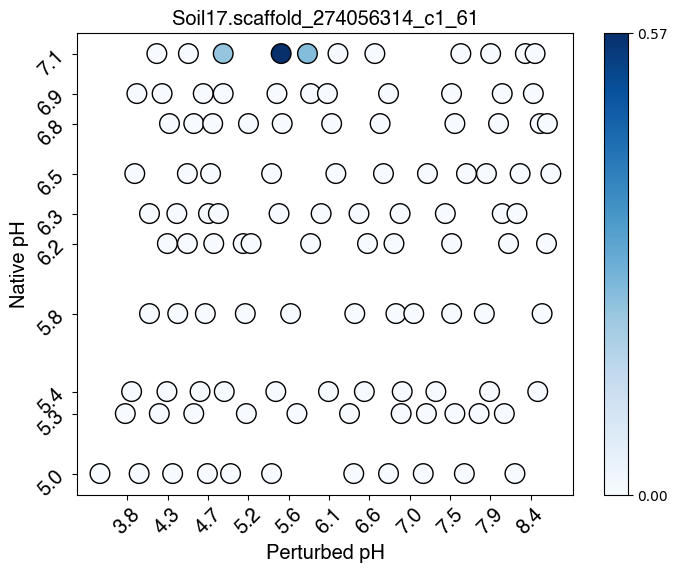

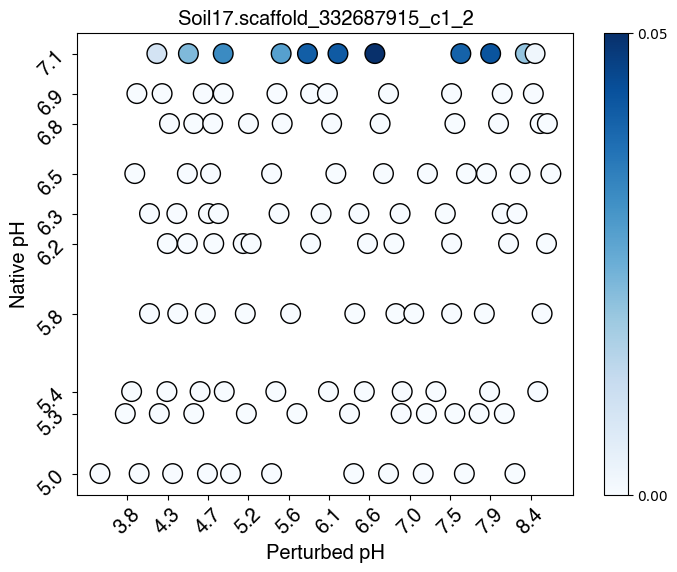

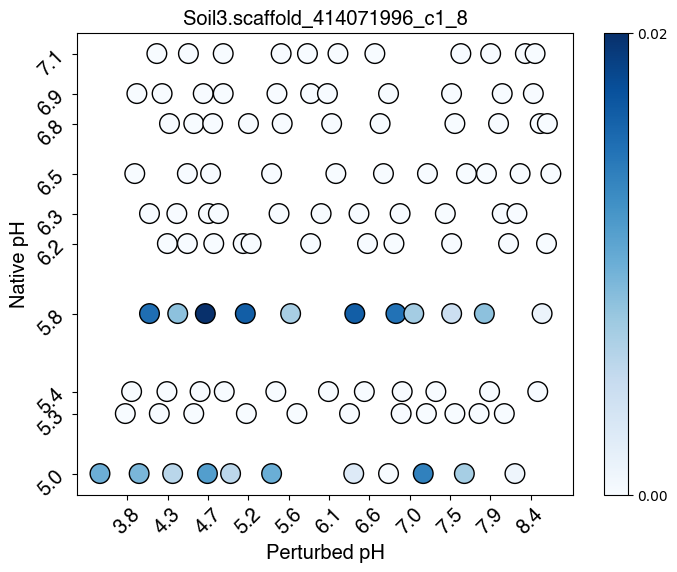

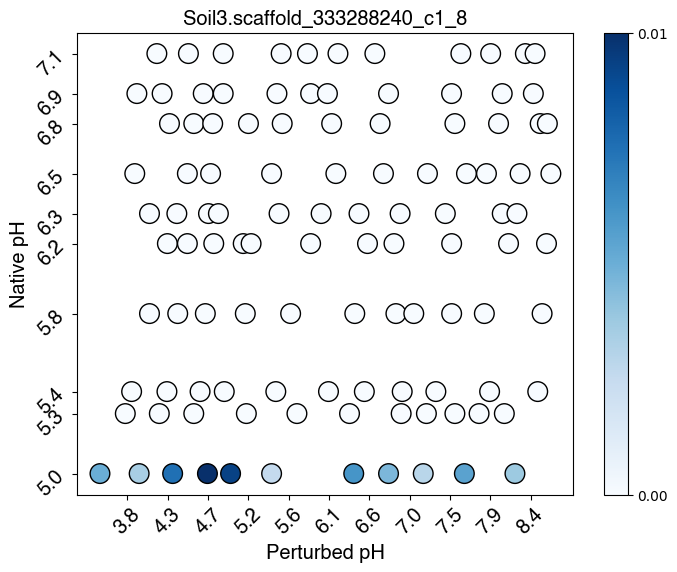

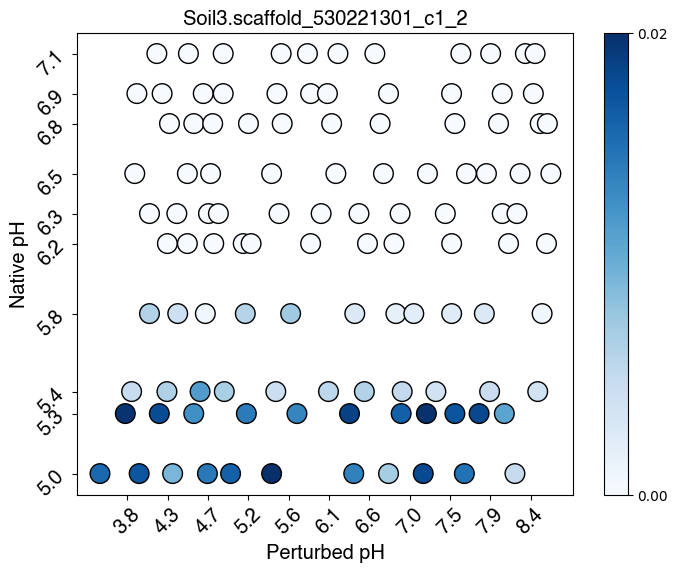

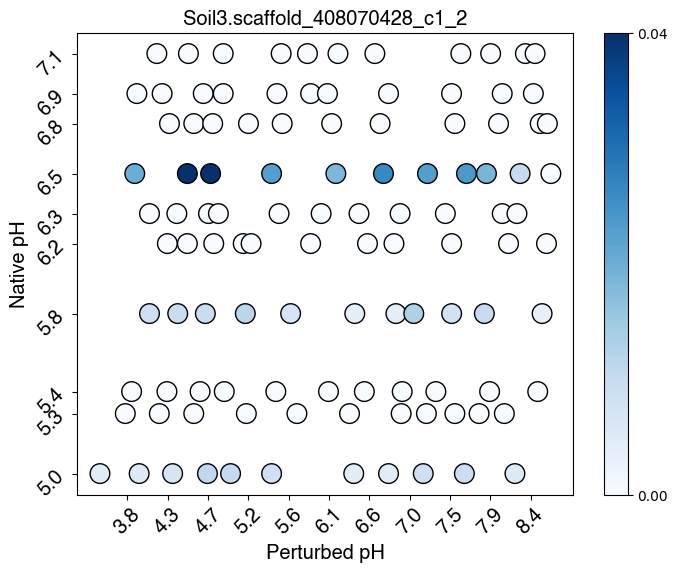

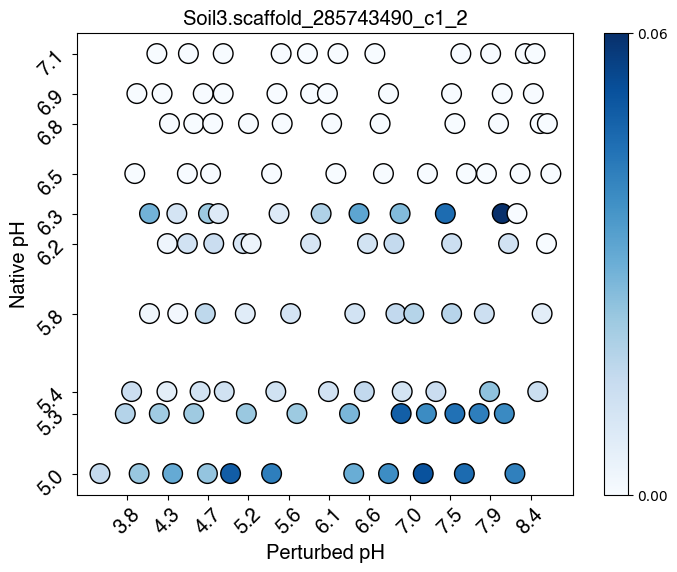

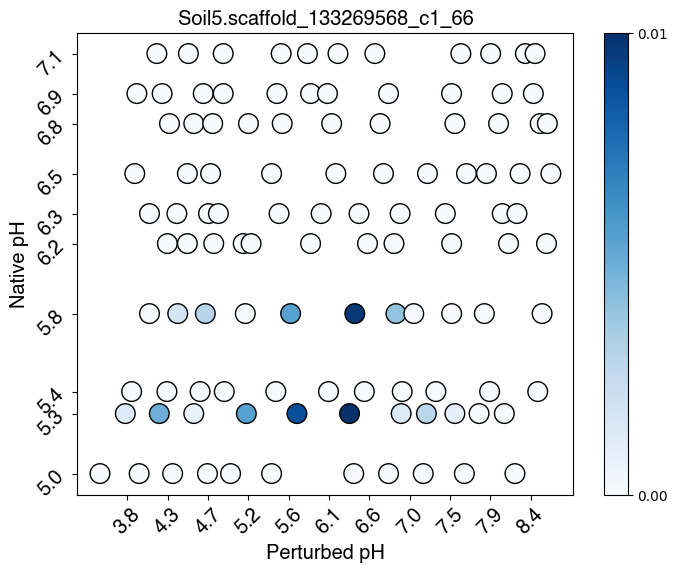

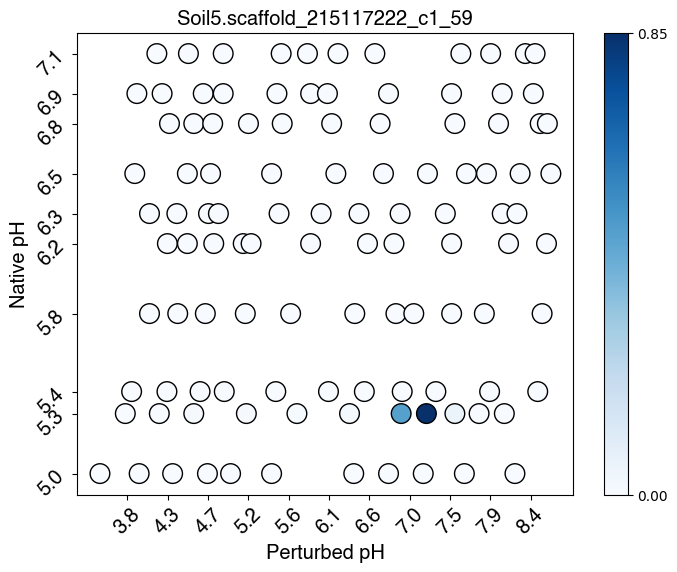

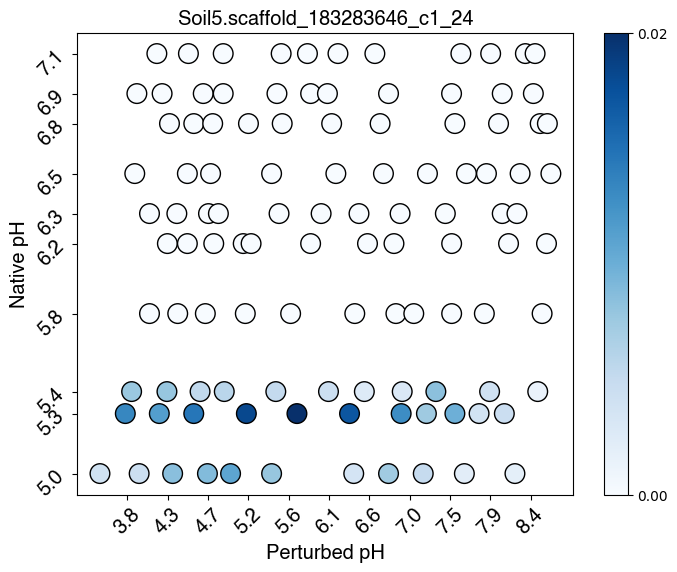

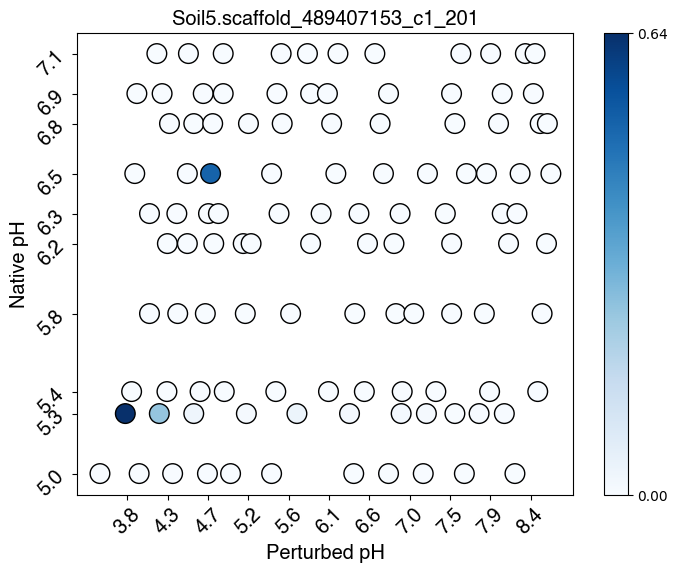

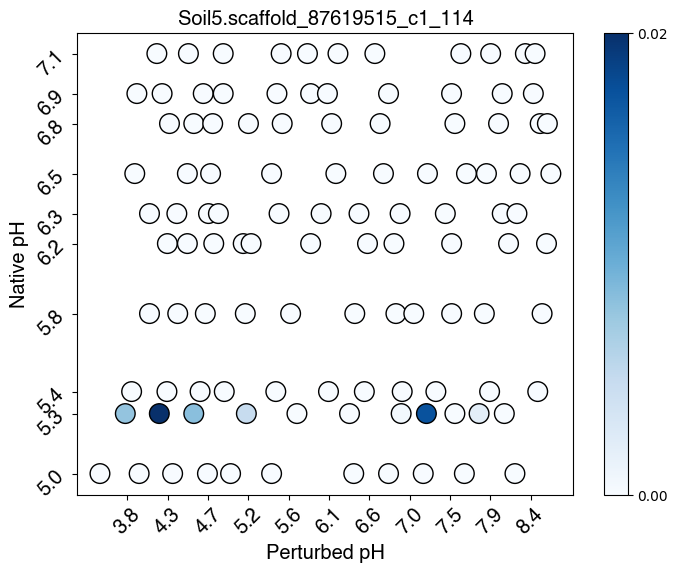

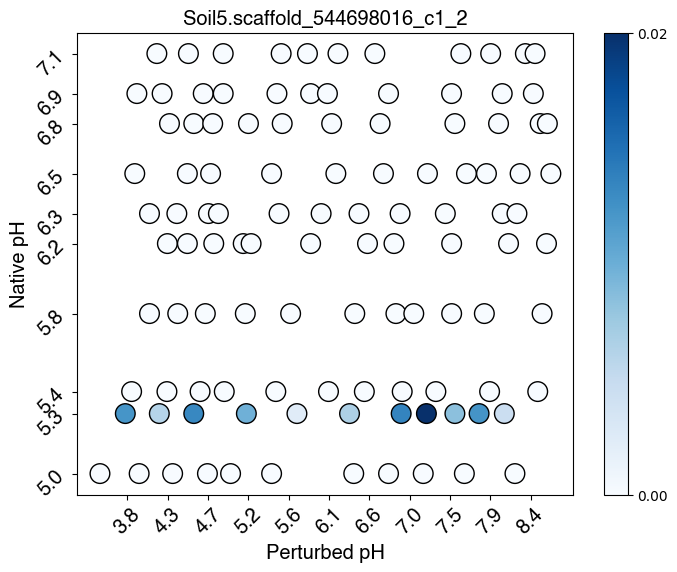

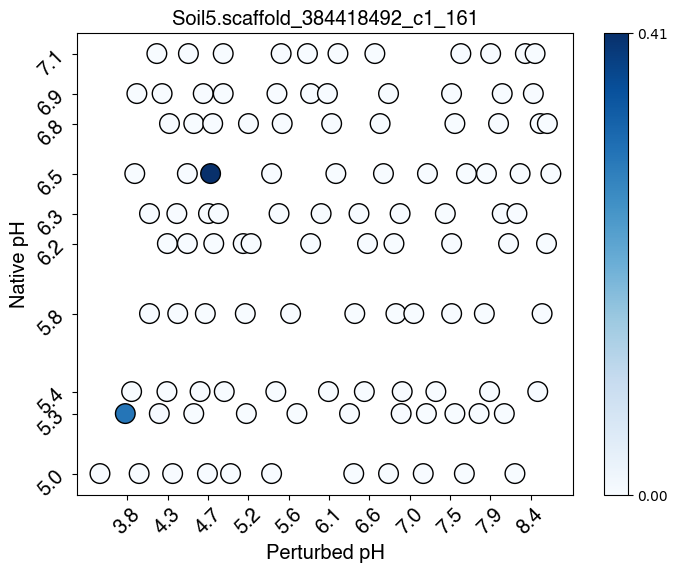

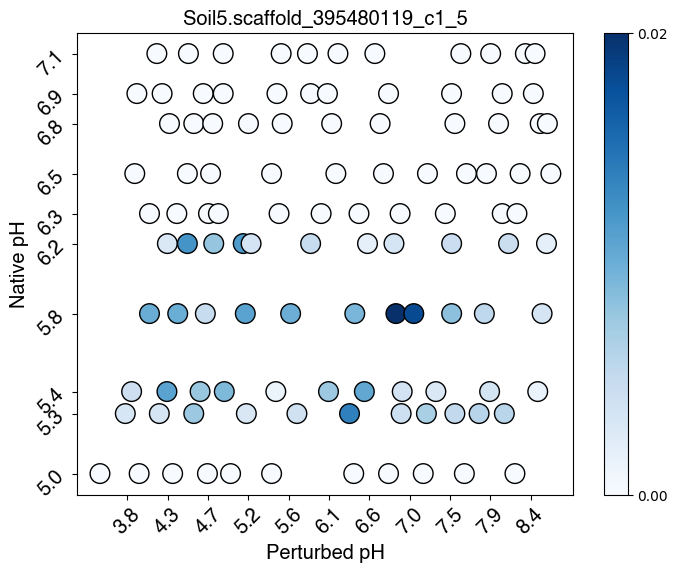

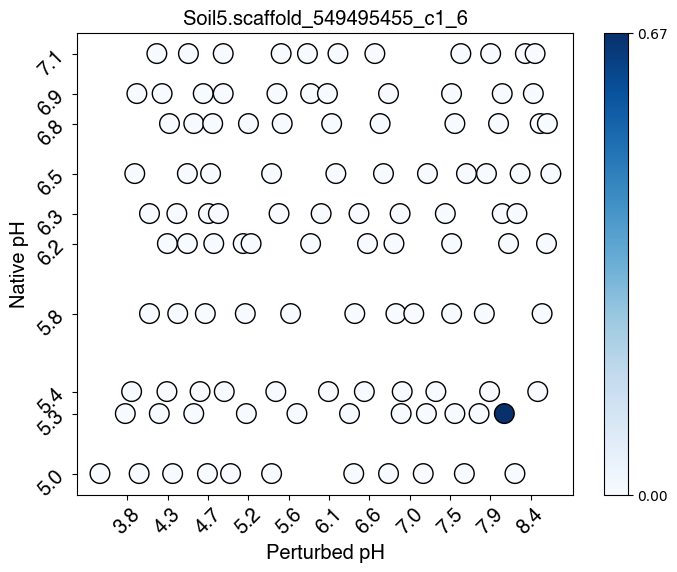

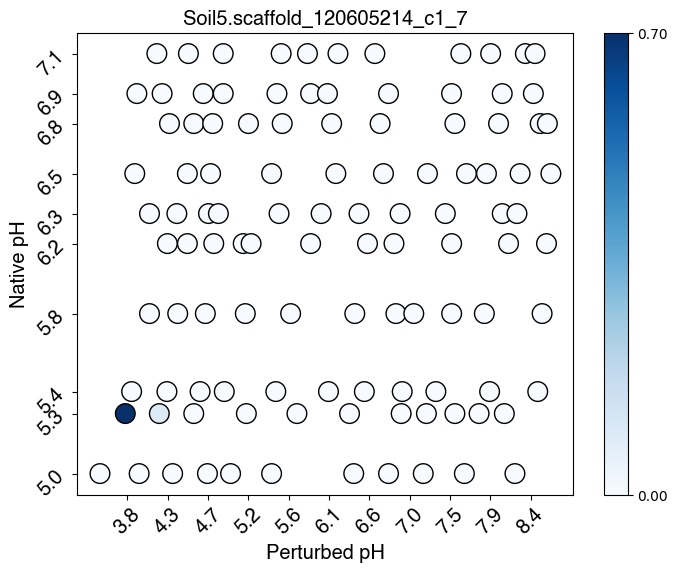

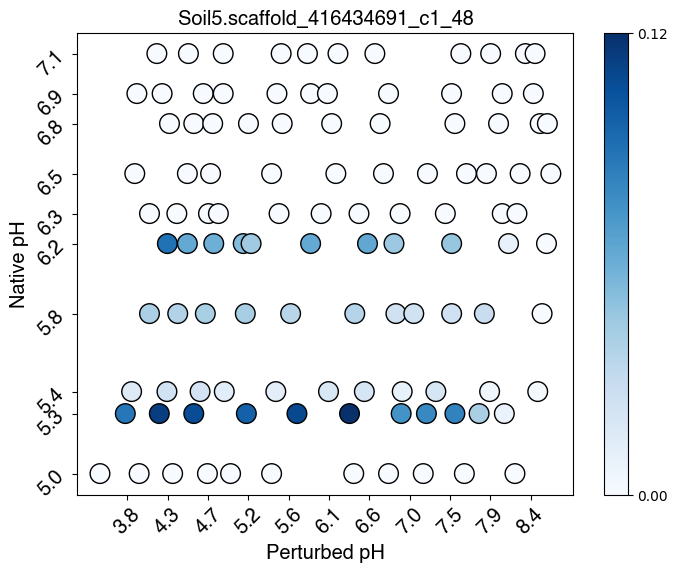

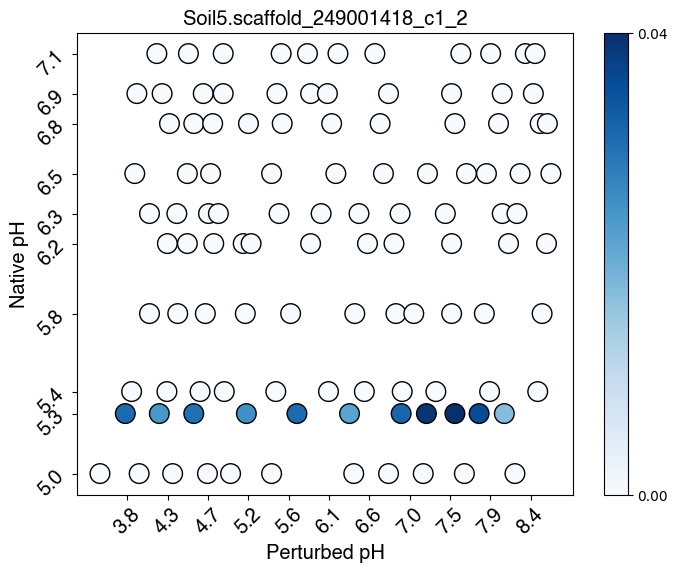

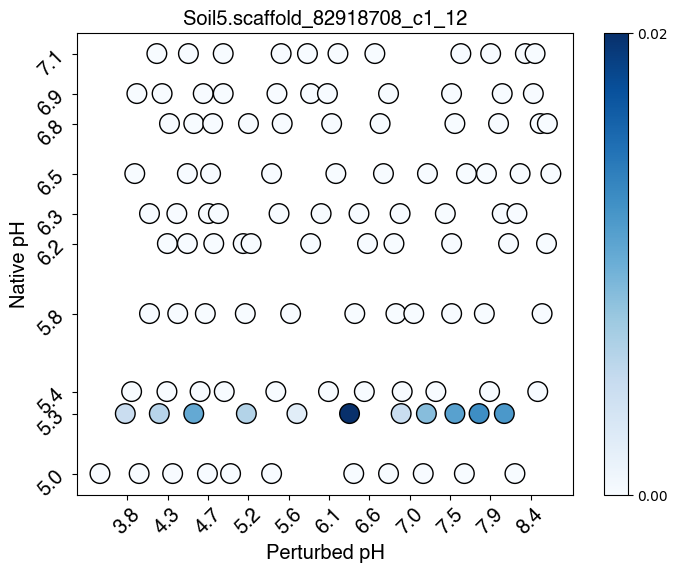

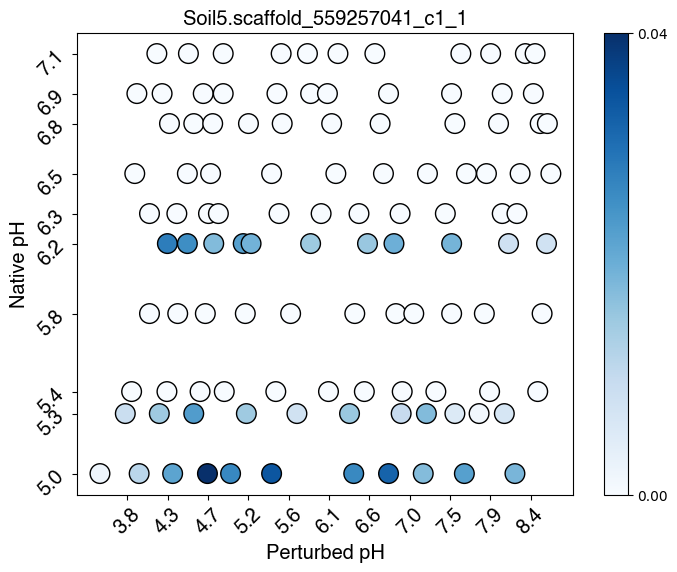

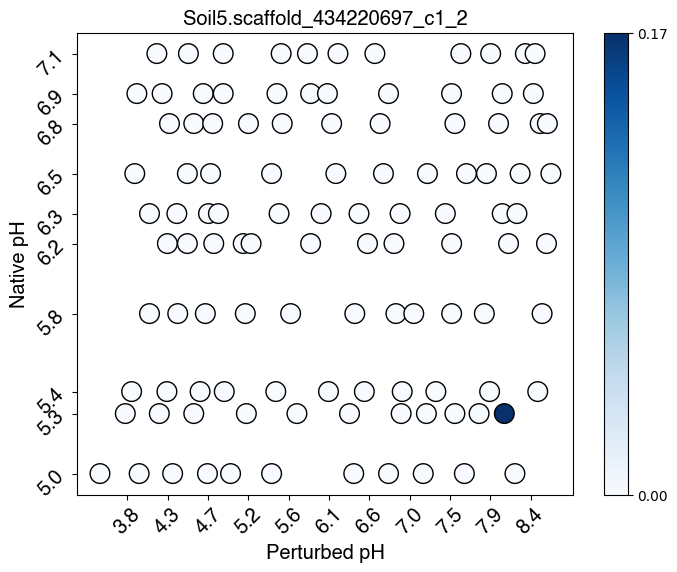

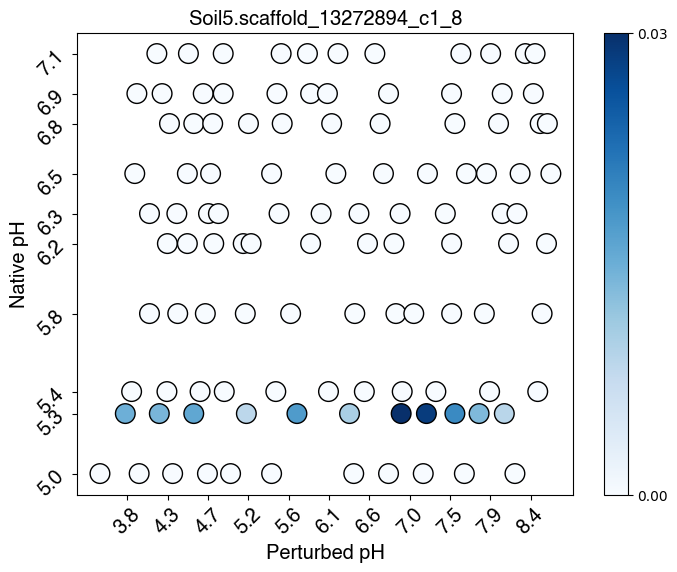

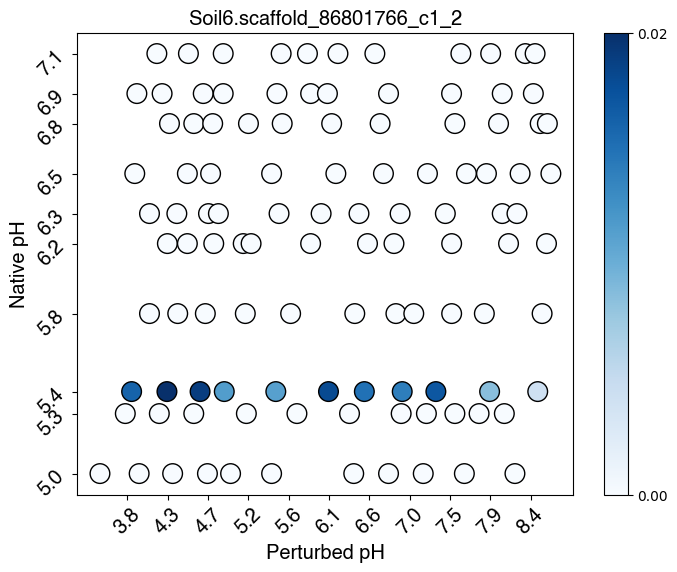

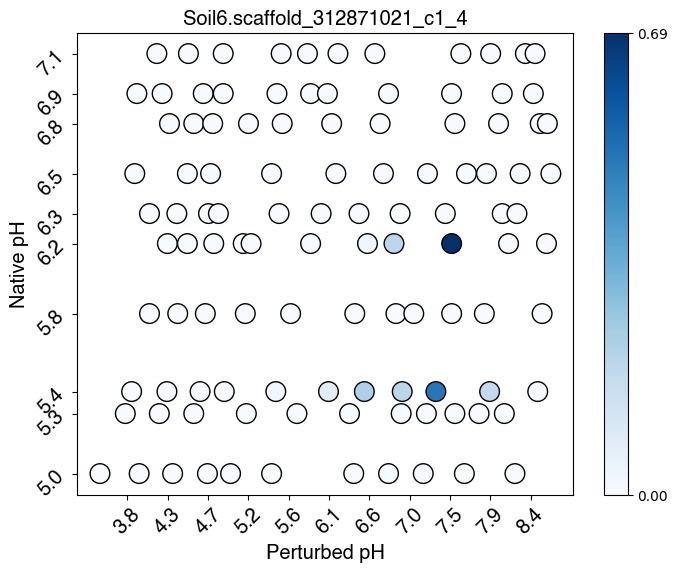

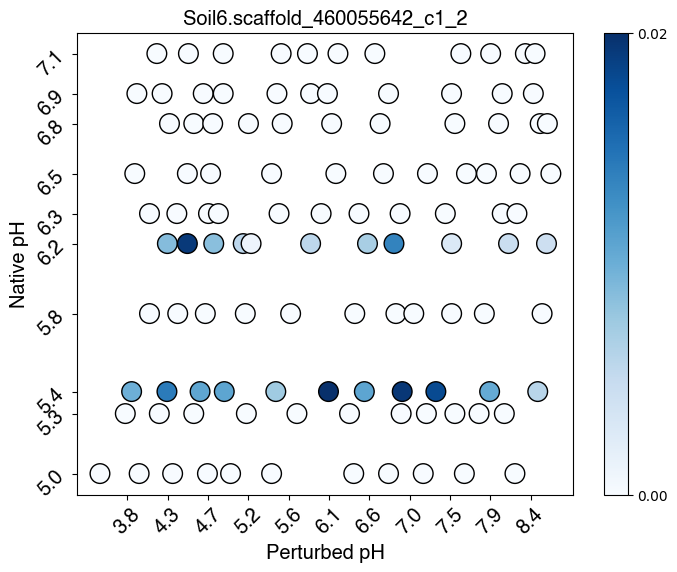

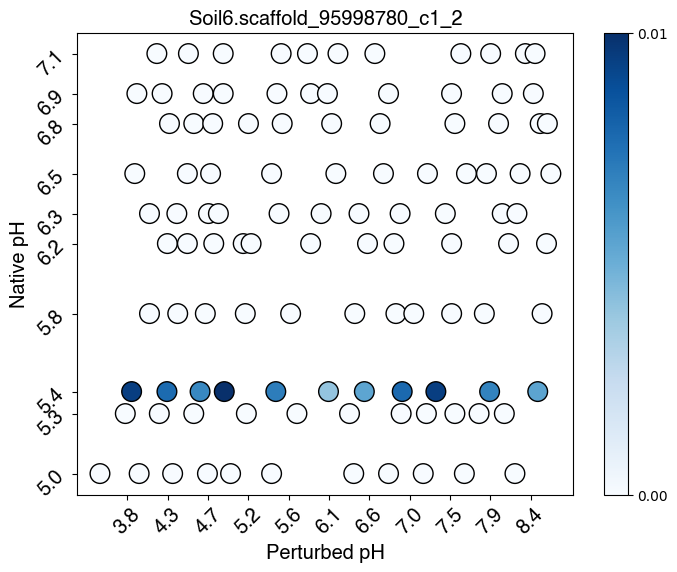

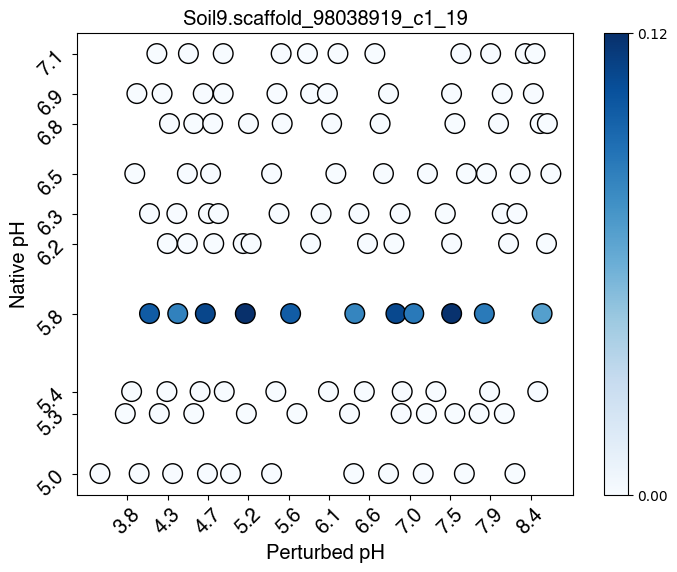

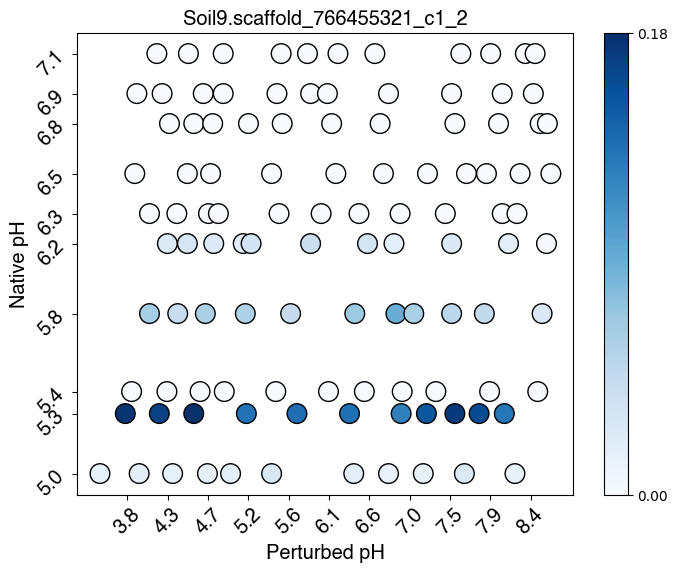

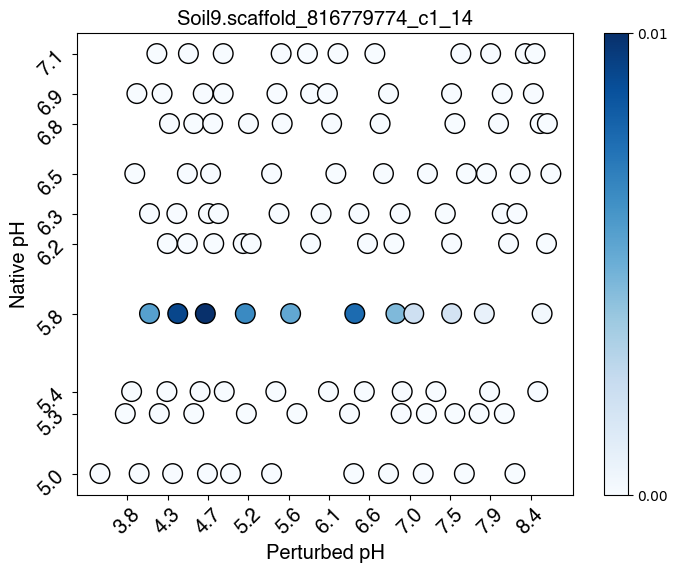

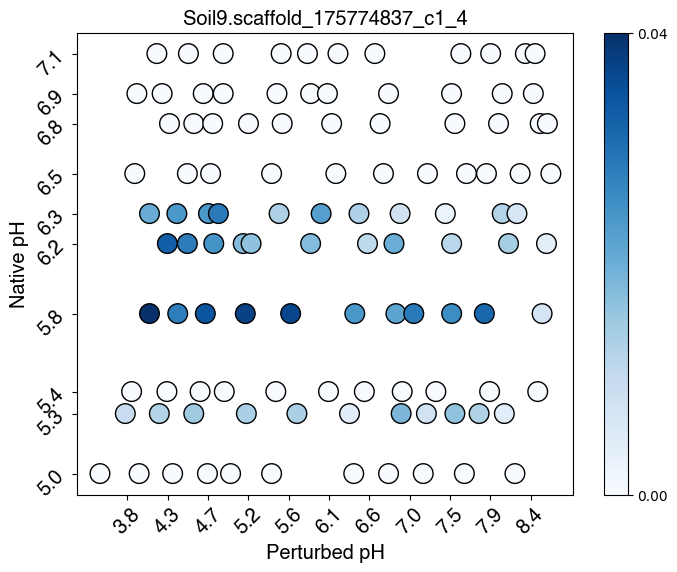

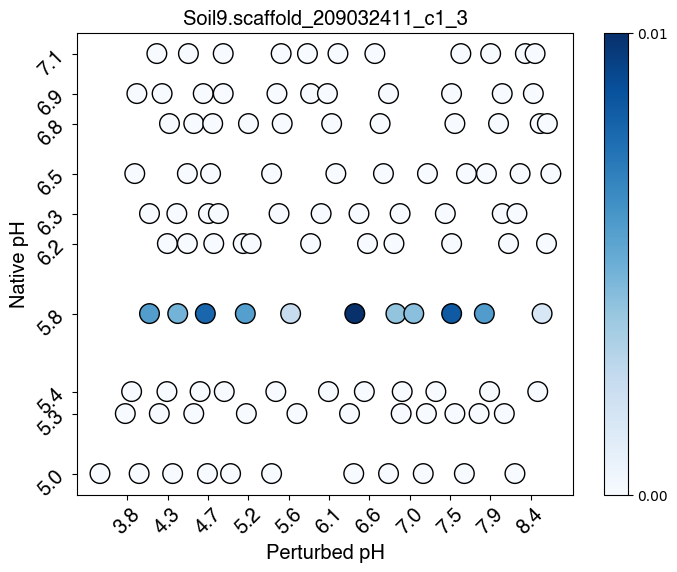

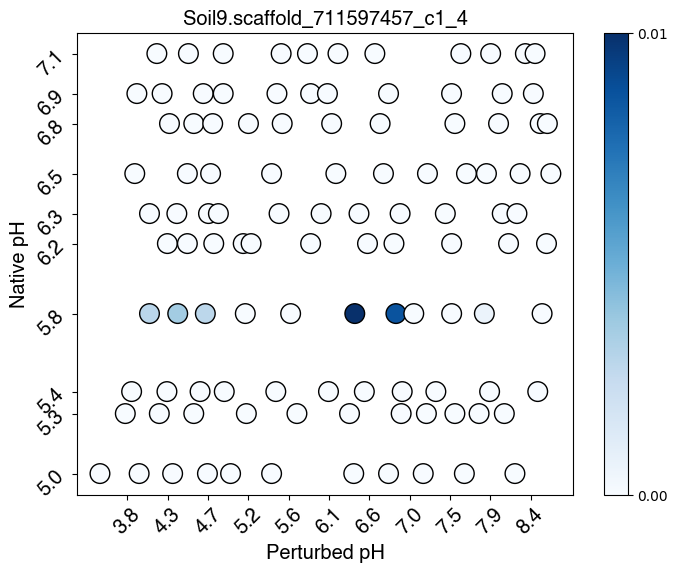

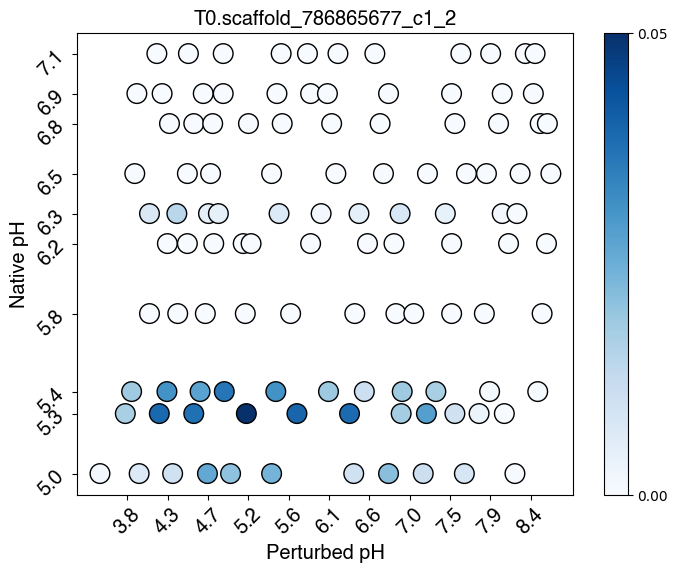

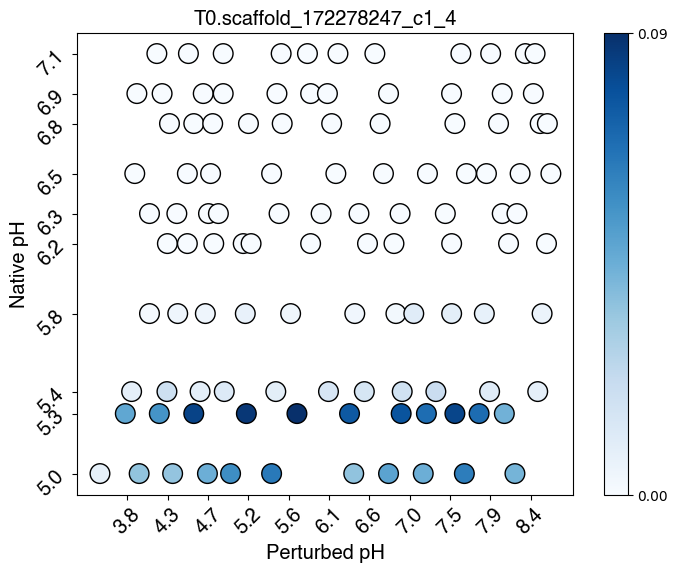

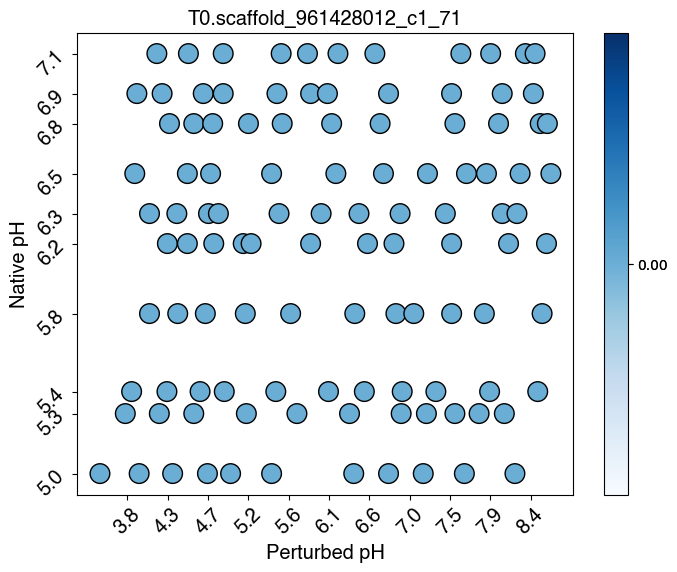

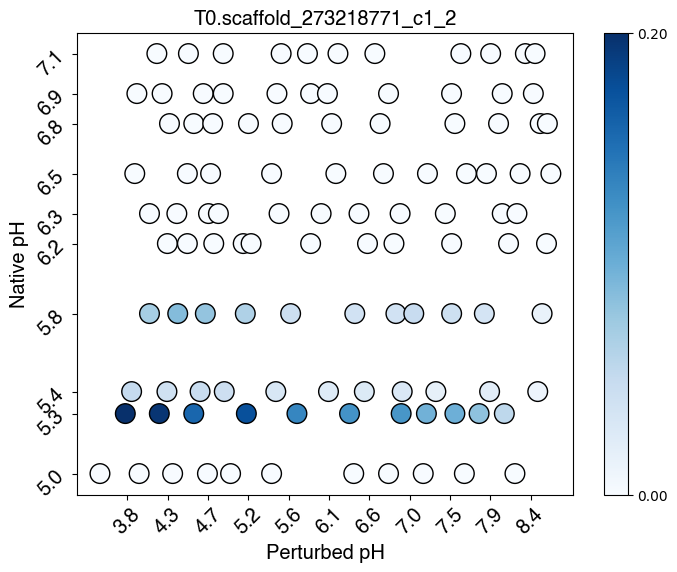

In [82]:
from mgsa.io import get_data

complete_seq_ids = pd.read_csv('../out/aaseqs/K00370/long_complete_orf_ids.txt', sep = '\t', header = None)
complete_seq_ids = complete_seq_ids.values
complete_seq_ids = [id[0] for id in complete_seq_ids]

for id in complete_seq_ids:
    plot(np.array(get_data(id)[1]), id)

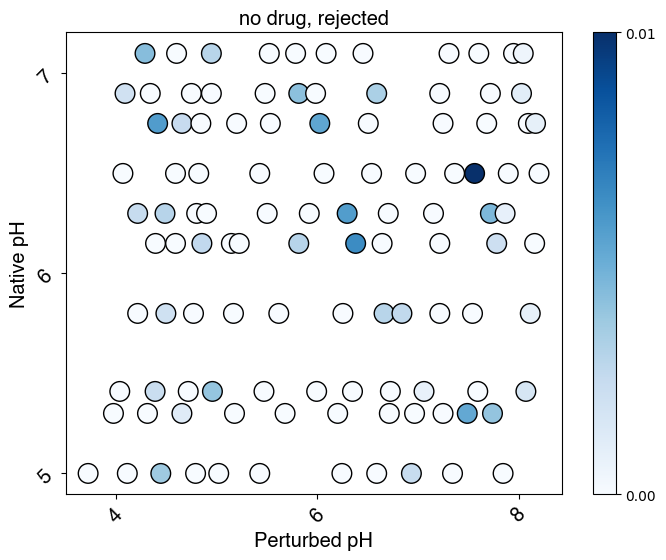

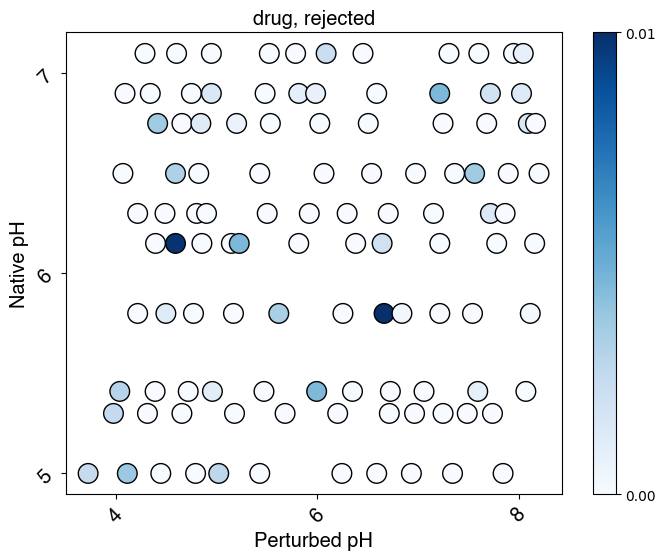

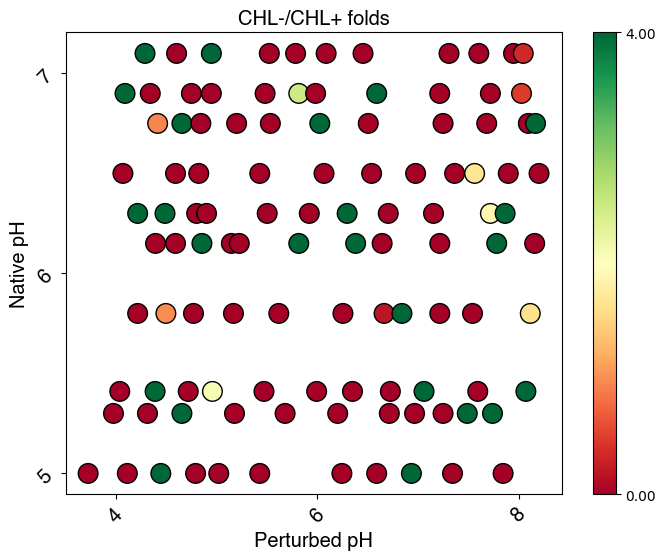

In [14]:
KO = 'K03385' 


table_path = '../data/KO_tables_corrected'

T0 = np.zeros((10, 11))
T9_acc_none = np.zeros((10, 11))
T9_acc_drug = np.zeros((10, 11))

T9_rej_none = np.zeros((10, 11))
T9_rej_drug = np.zeros((10, 11))

#load the header
header = pd.read_csv(f'{table_path}/chl_neg_samples_corrected.csv', nrows=0).columns.tolist()
first_col = header[0]

filtered_chl_neg = pd.read_csv(f'{table_path}/chl_neg_samples_corrected.csv' , usecols=[first_col, KO]).fillna(0)
filtered_chl_pos = pd.read_csv(f'{table_path}/chl_pos_samples_corrected.csv' , usecols=[first_col, KO]).fillna(0)

sample_list = filtered_chl_neg['Unnamed: 0'].values

def get_total_spikein(file_path, sample_id):
    #collect the total spikein in a specified sample
    #filepath is path to KO table
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split('\t')
            if parts[0] == sample_id:
                return float(parts[-2])
    return 0

def get_sample_idx(sample_list, sample_id):
    for idx, sample in enumerate(sample_list):
        if sample == sample_id:
            return idx
    return 0


##Collect data for rejected reads

for soil in soils:
    sample_ids = samples(soil, drug = 'None')
    file_path = f'../data/KO_table/{soil}.KO_absolute_average_depth.tsv'
    row_idx = soils.index(soil)
    for sample in sample_ids:
        col_idx = sample_ids.index(sample)
        idx = get_sample_idx(sample_list, sample)
        total_spikein = get_total_spikein(file_path, sample)
        filtered_reads_neg = filtered_chl_neg[KO].values
        filtered_reads_pos = filtered_chl_pos[KO].values
        if idx < 109:
            T9_rej_none[row_idx][col_idx] = filtered_reads_neg[idx]/total_spikein
            T9_rej_drug[row_idx][col_idx] = filtered_reads_pos[idx]/total_spikein
    

plot(T9_rej_none, 'no drug, rejected')
plot(T9_rej_drug, 'drug, rejected')
plot(T9_rej_none / (T9_rej_drug + 0.0001), 'CHL-/CHL+ folds', vmin = 0, vmax = 4, cmap = 'RdYlGn')

# np.savetxt(f'../out/KO_abundances/T9data_{KO}_CHL_rej.tsv', T9_rej_drug, delimiter = '\t', fmt = '%0.6f')